In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn
import numpy as np
import tensorflow as tf


In [35]:
train_df = pd.read_csv("/Users/advaysingh/Downloads/house-prices-advanced-regression-techniques/train.csv")
test_df = pd.read_csv("/Users/advaysingh/Downloads/house-prices-advanced-regression-techniques/test.csv")

In [36]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [38]:
train_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [39]:
train_df.drop(['Id'], axis=1, inplace=True)

In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [41]:
train_df.shape

(1460, 80)

In [42]:
train_df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [43]:
#drop columns whose non-null values are less than 1000
train_df = train_df.dropna(thresh=1000, axis=1)
train_df.shape


(1460, 74)

In [44]:
#get info about categorical features
train_df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1460 non-null   object
 1   Street         1460 non-null   object
 2   LotShape       1460 non-null   object
 3   LandContour    1460 non-null   object
 4   Utilities      1460 non-null   object
 5   LotConfig      1460 non-null   object
 6   LandSlope      1460 non-null   object
 7   Neighborhood   1460 non-null   object
 8   Condition1     1460 non-null   object
 9   Condition2     1460 non-null   object
 10  BldgType       1460 non-null   object
 11  HouseStyle     1460 non-null   object
 12  RoofStyle      1460 non-null   object
 13  RoofMatl       1460 non-null   object
 14  Exterior1st    1460 non-null   object
 15  Exterior2nd    1460 non-null   object
 16  ExterQual      1460 non-null   object
 17  ExterCond      1460 non-null   object
 18  Foundation     1460 non-null

In [46]:
from sklearn.impute import SimpleImputer

# Create the imputer with the 'most_frequent' strategy
imputer = SimpleImputer(strategy='most_frequent')

# Loop through each categorical column and apply the imputation
for column in train_df.select_dtypes(include=['object']).columns:
    train_df[column] = imputer.fit_transform(train_df[[column]]).ravel()

# Check if missing values are gone
train_df.select_dtypes(include=['object']).isnull().sum()


MSZoning         0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinType2     0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
KitchenQual      0
Functional       0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
SaleType         0
SaleCondition    0
dtype: int64

In [47]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [48]:
train_df.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125
1459,20,RL,75.0,9937,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2008,WD,Normal,147500


In [49]:
numerical_data = train_df.select_dtypes(include=['int64', 'float64'])
numerical_data.isnull().sum()

MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [50]:

train_df = train_df.apply(
    lambda x: x.fillna(x.mean()) if np.issubdtype(x.dtype, np.number) else x, axis=0
)


In [51]:
train_df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 74, dtype: int64

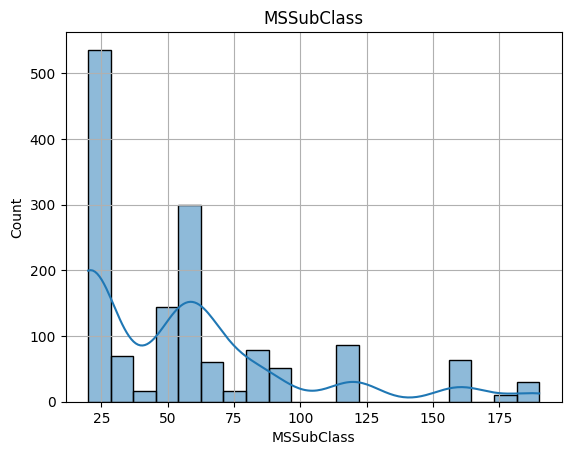

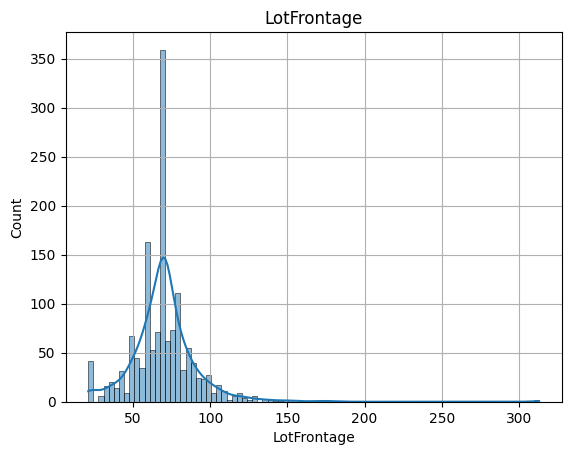

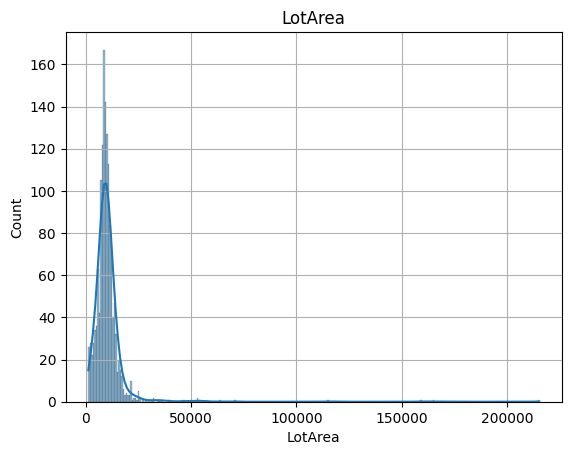

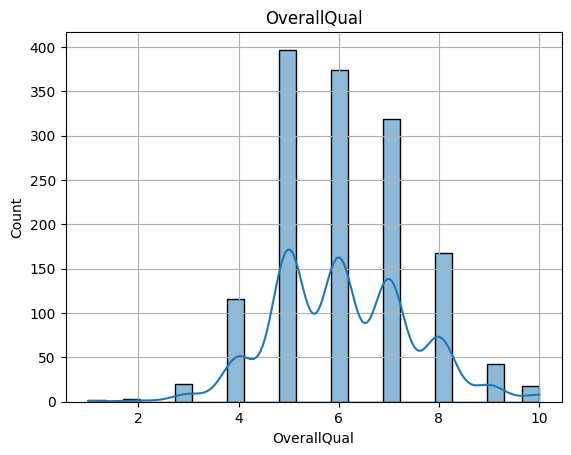

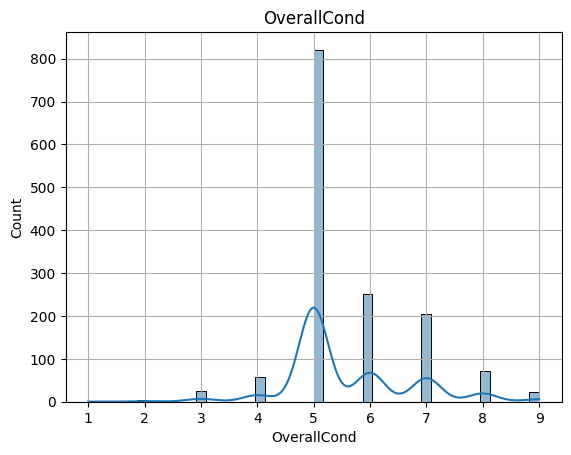

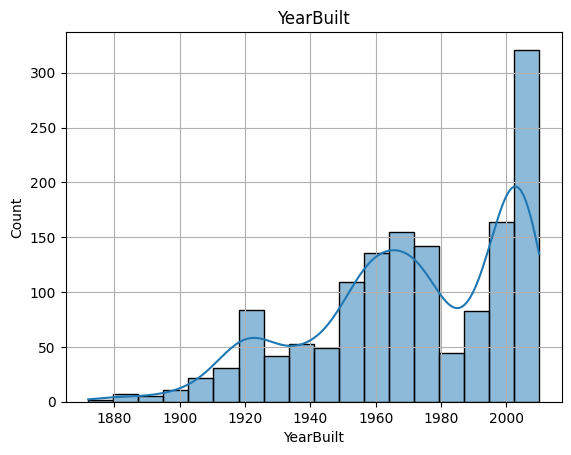

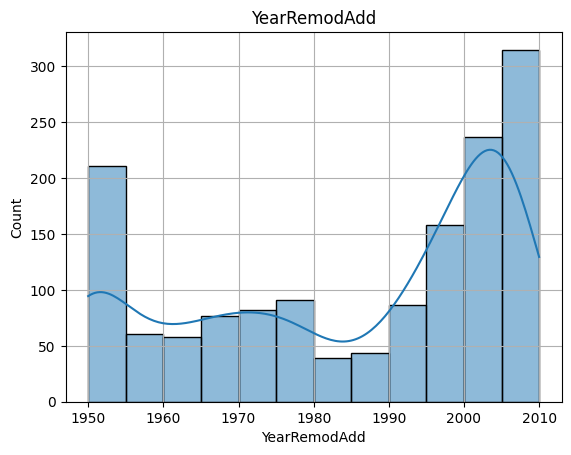

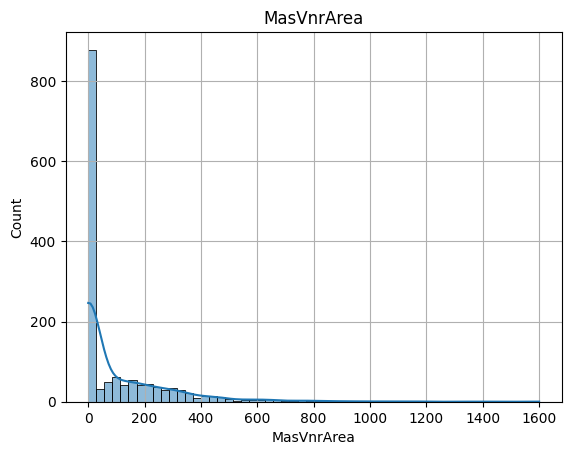

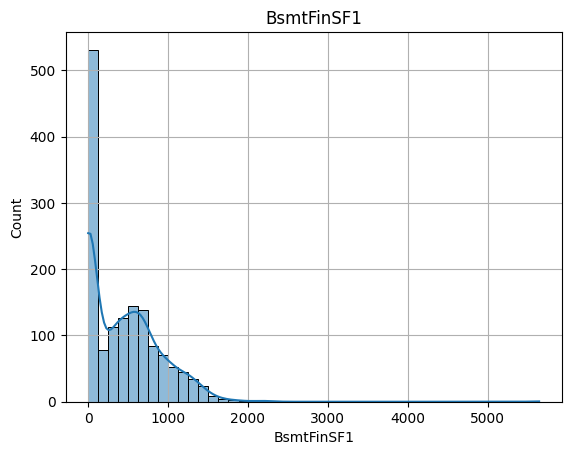

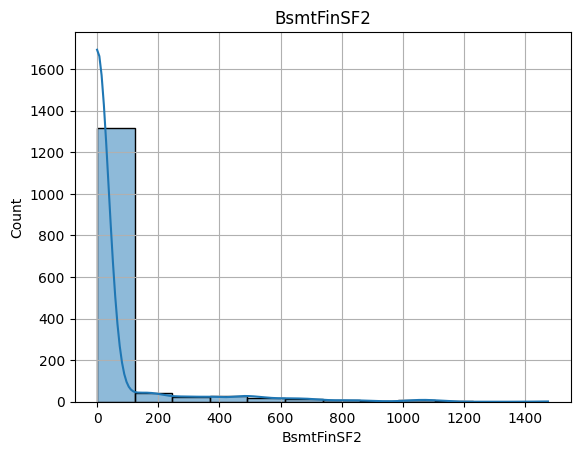

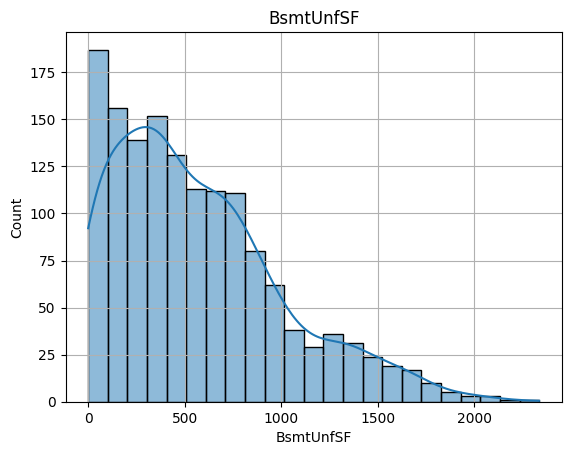

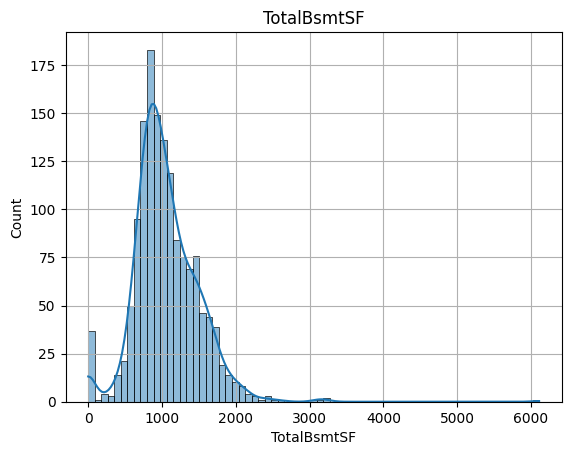

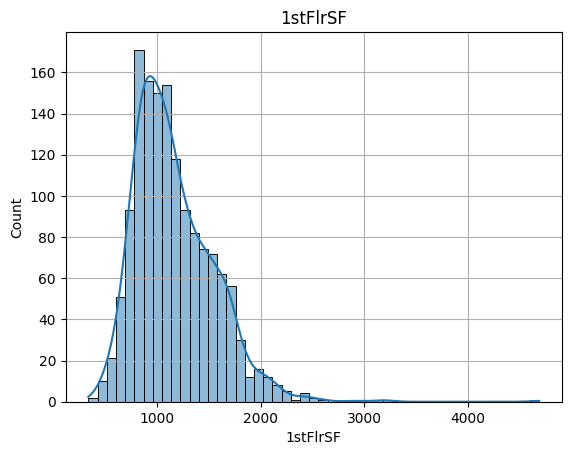

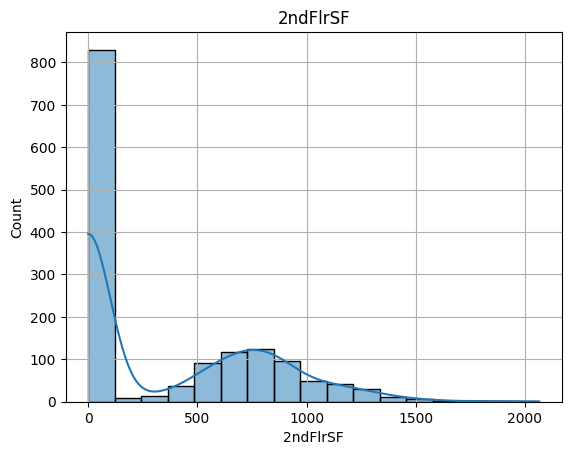

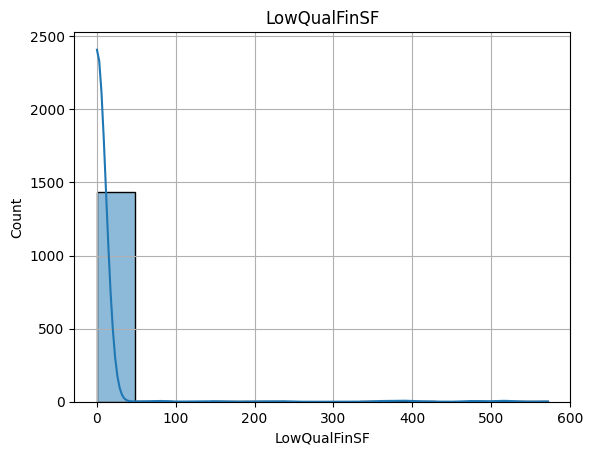

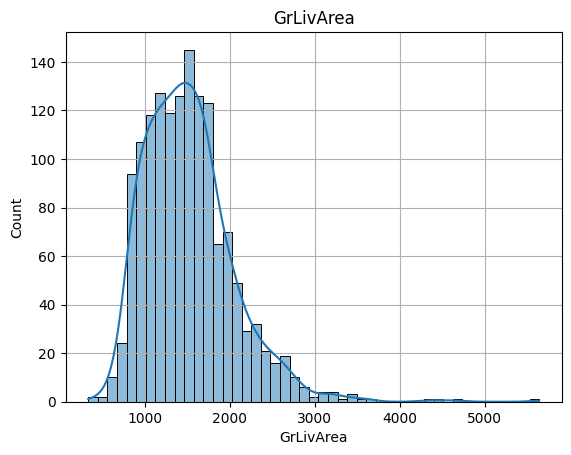

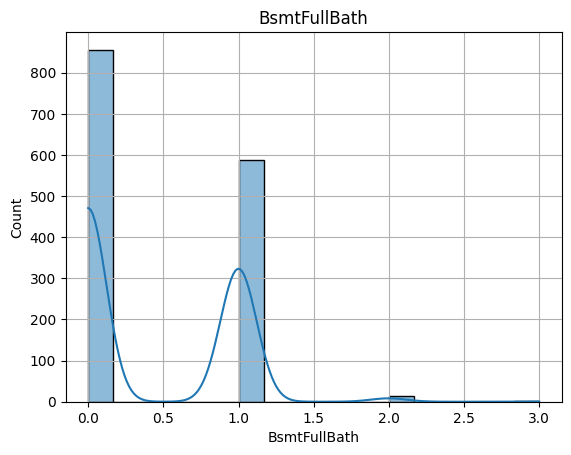

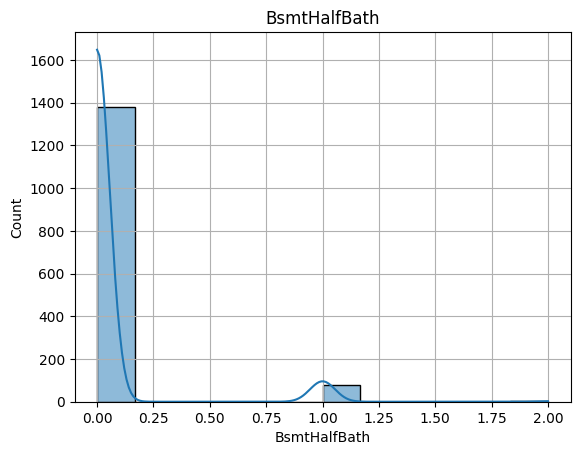

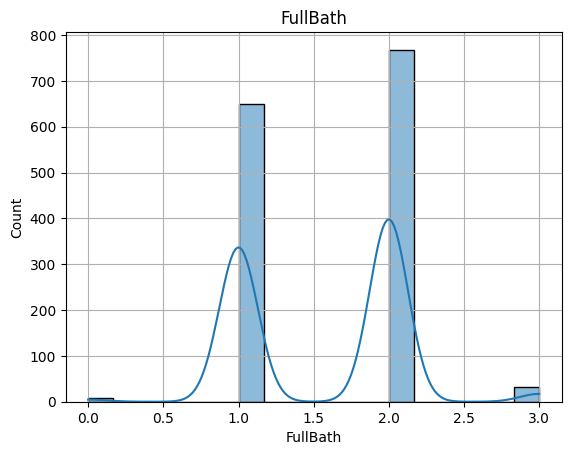

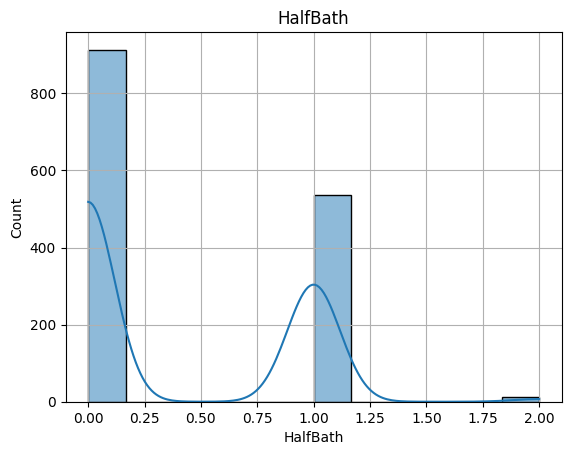

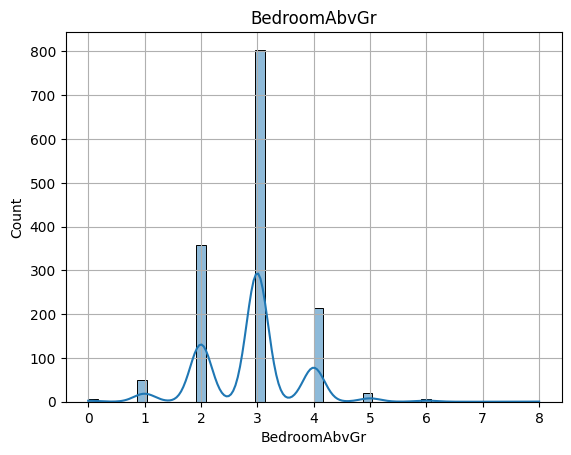

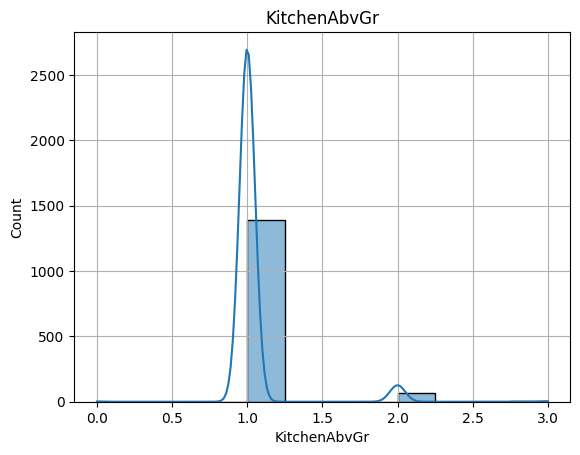

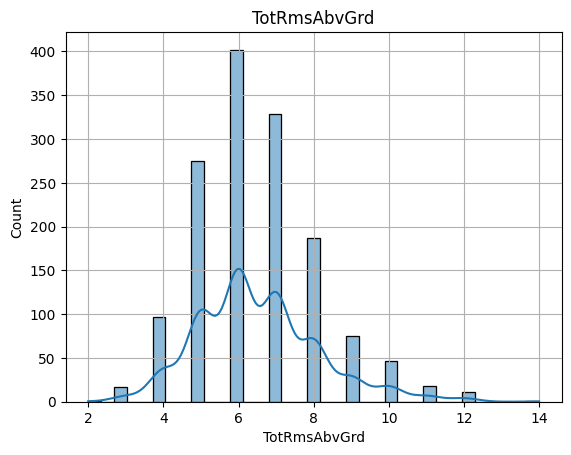

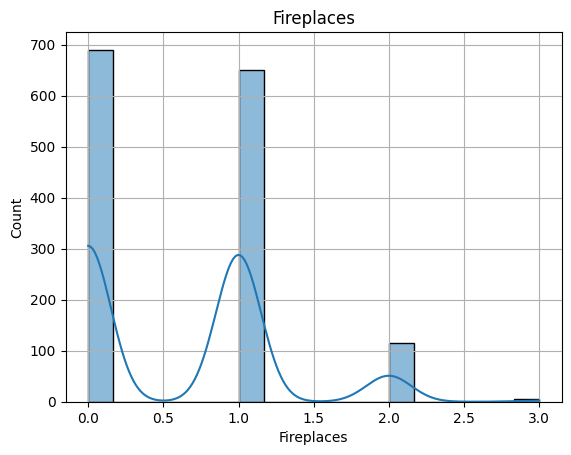

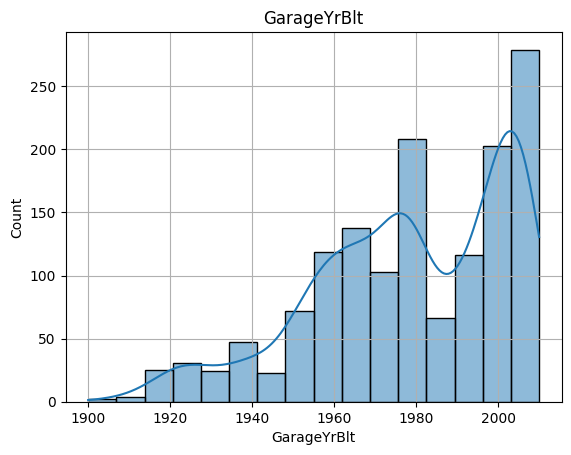

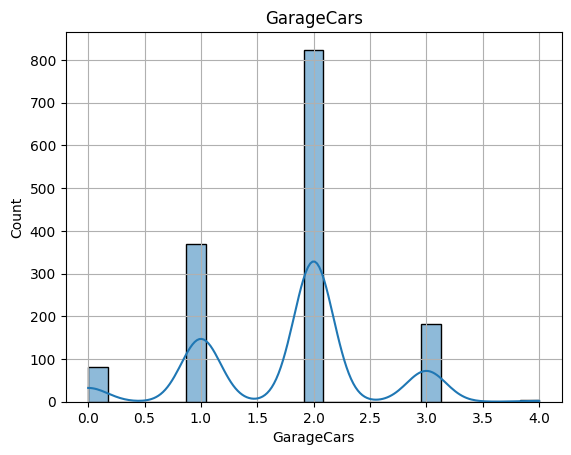

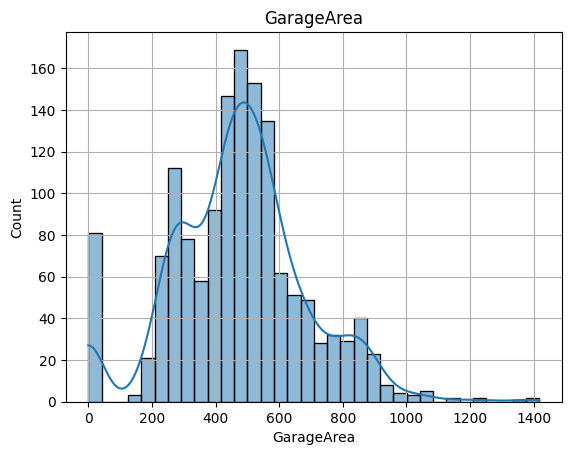

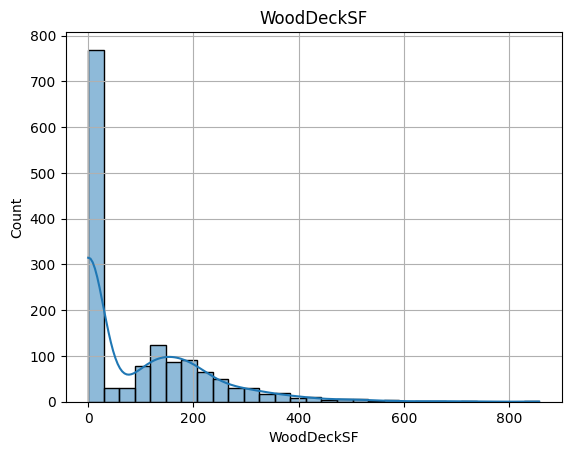

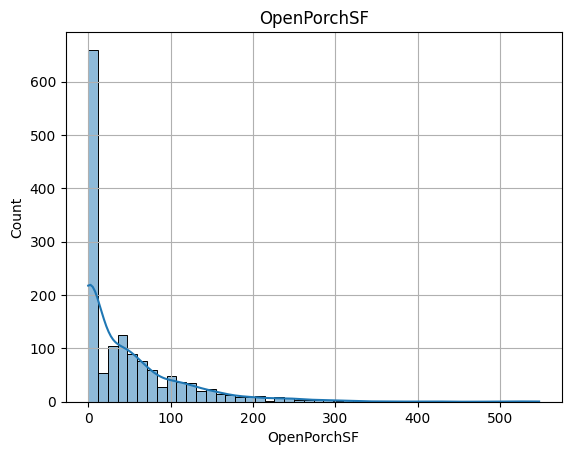

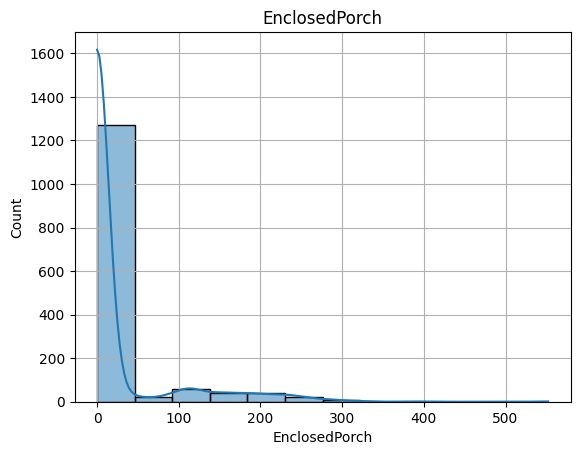

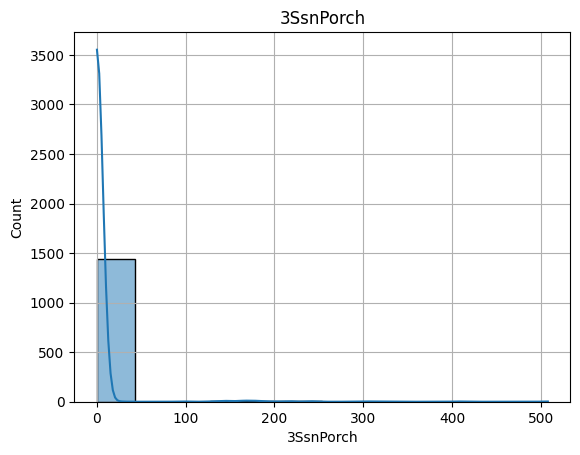

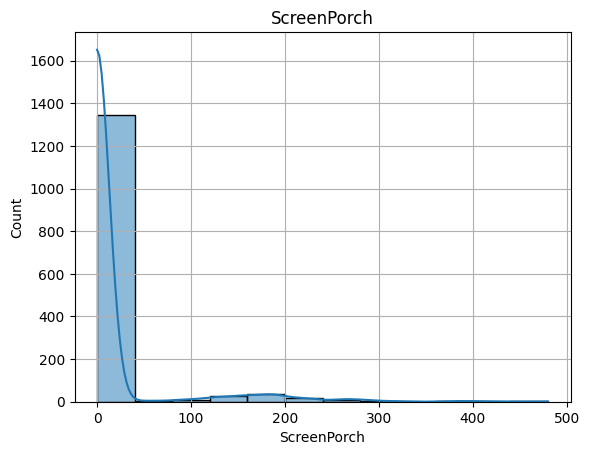

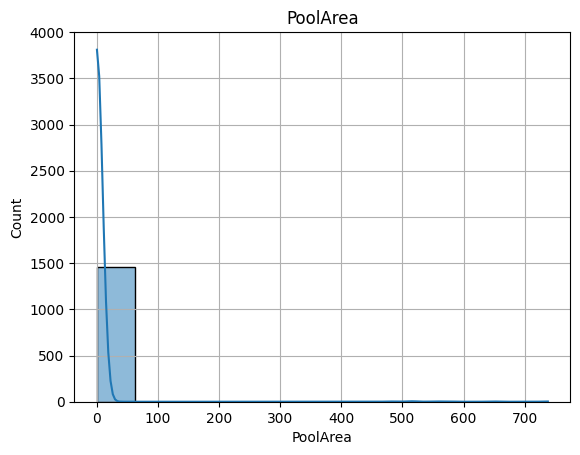

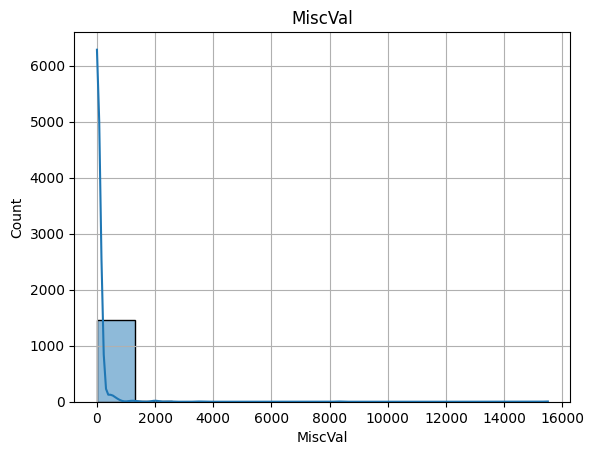

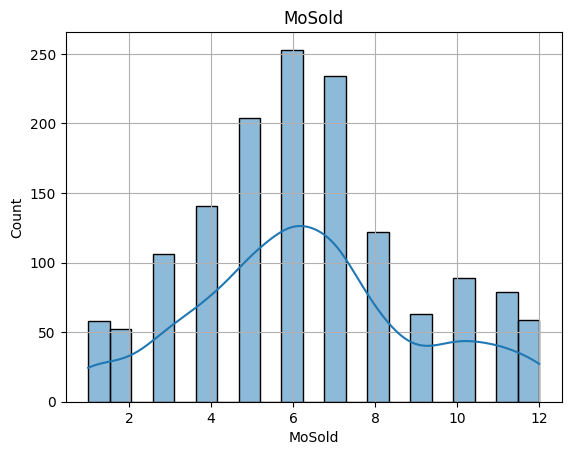

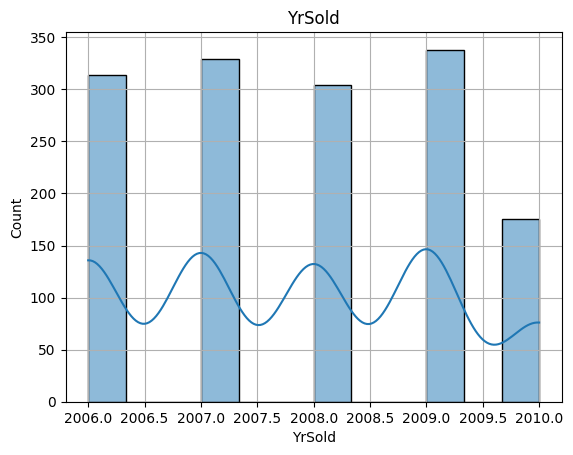

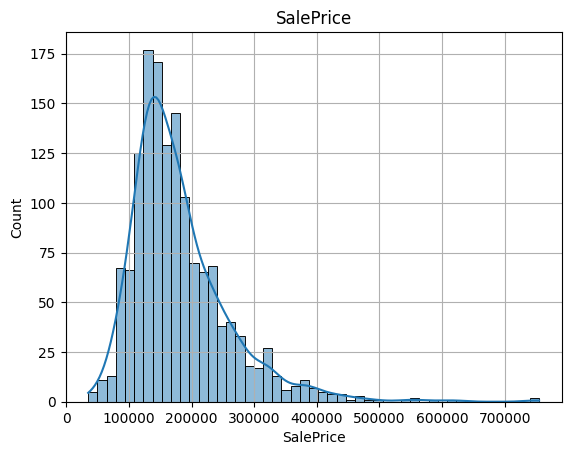

In [52]:
#distrubtion of each numerical column
for col in numerical_data.columns:
    sns.histplot(train_df[col], kde=True)
    plt.title(col)
    plt.grid(True)
    plt.show()

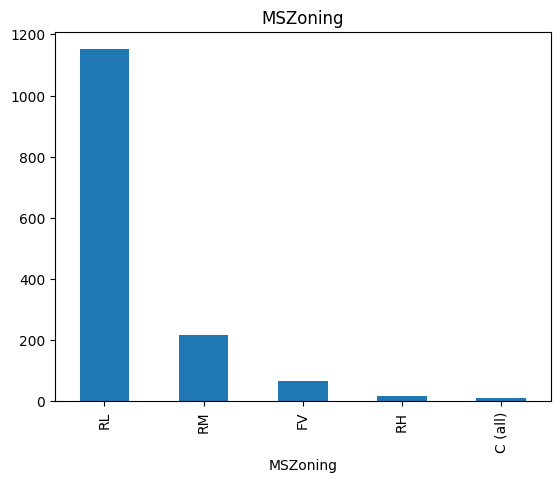

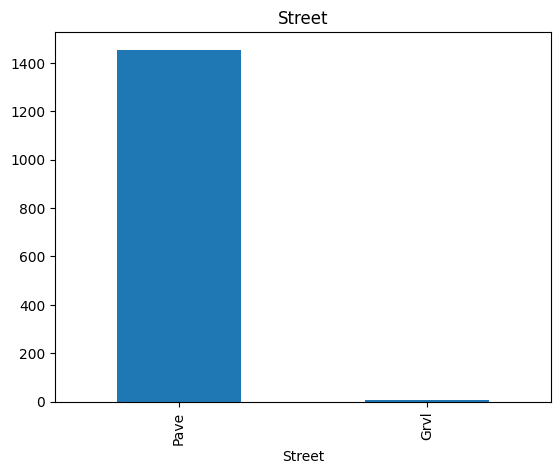

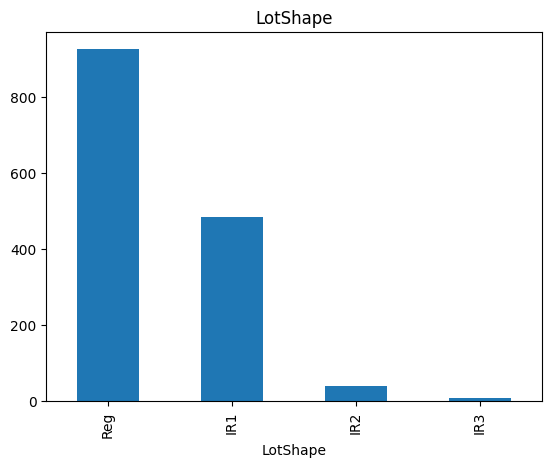

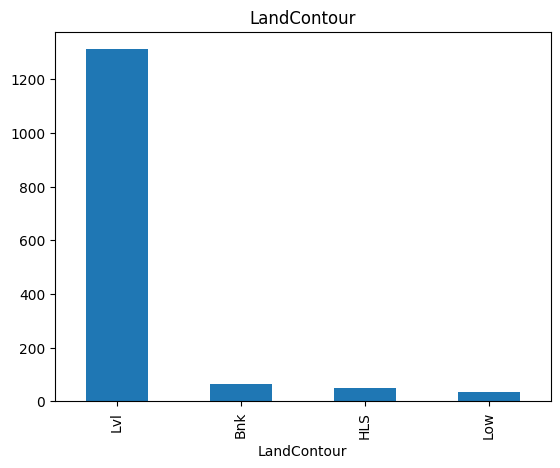

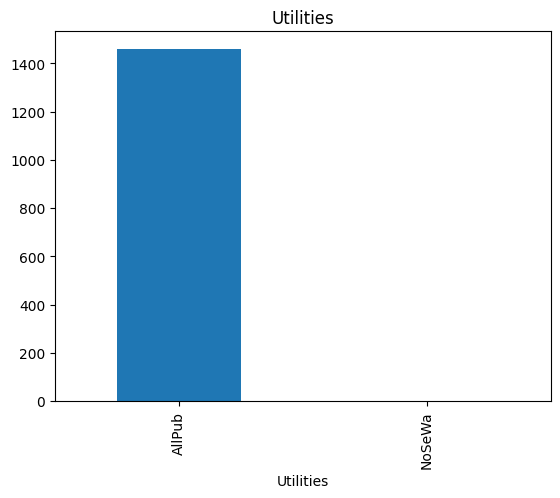

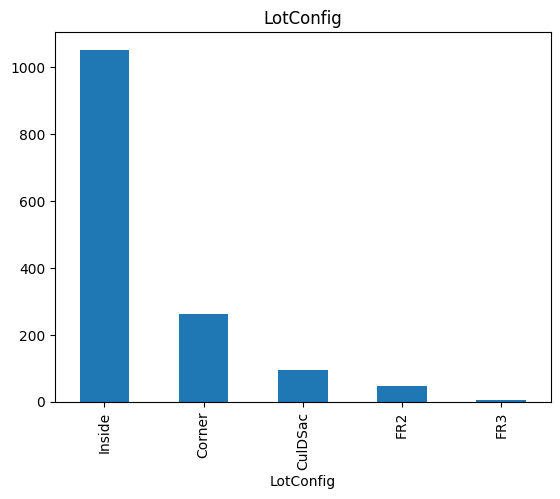

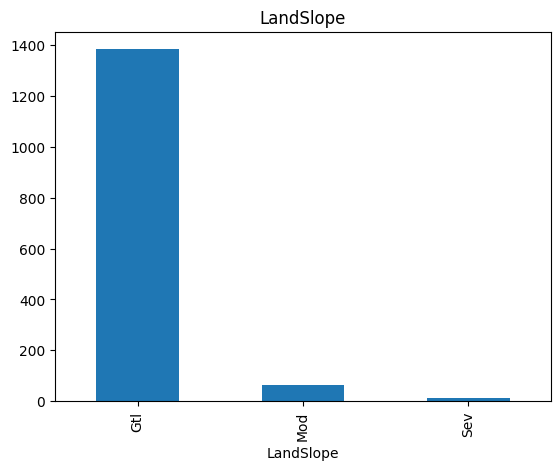

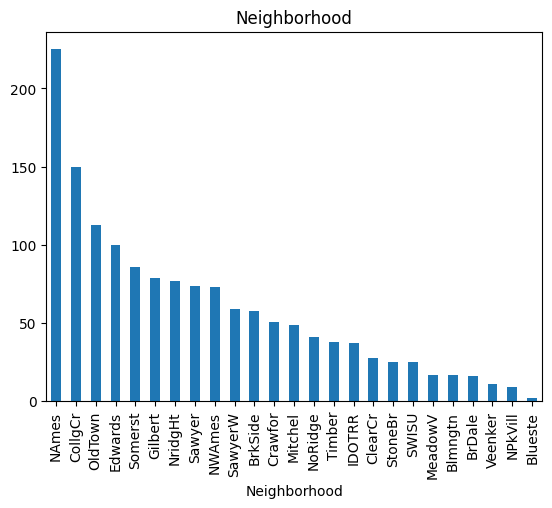

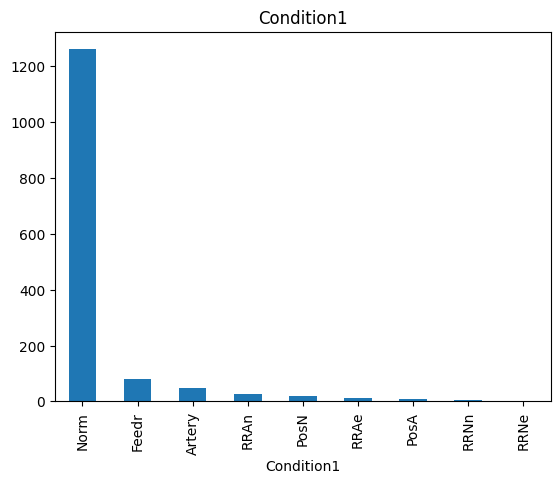

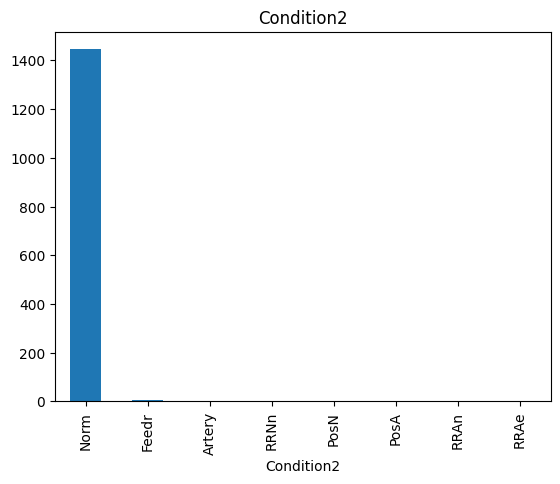

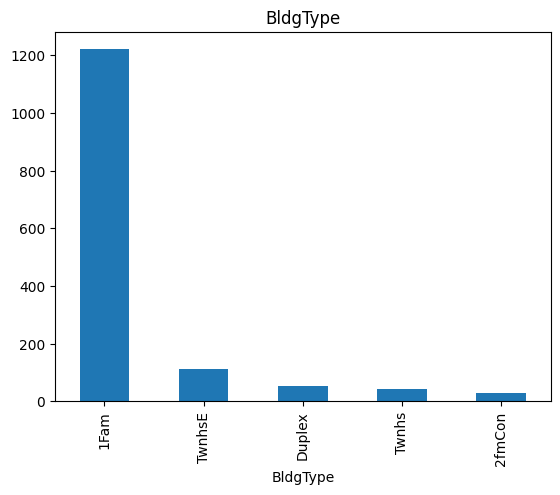

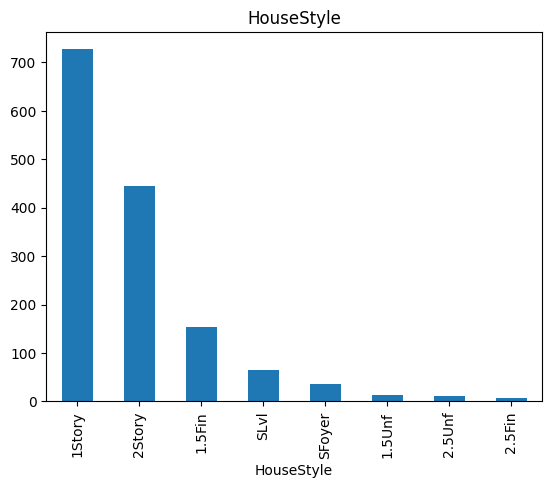

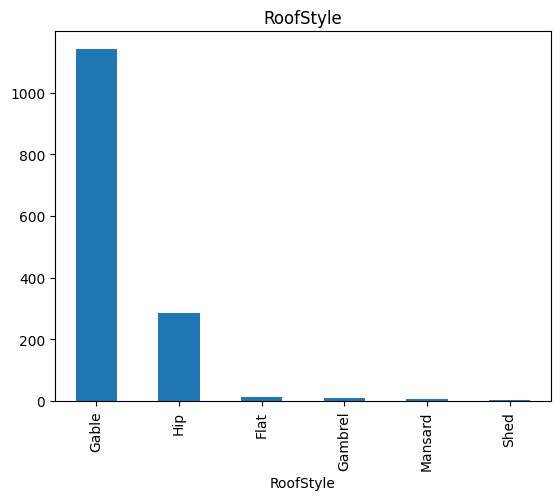

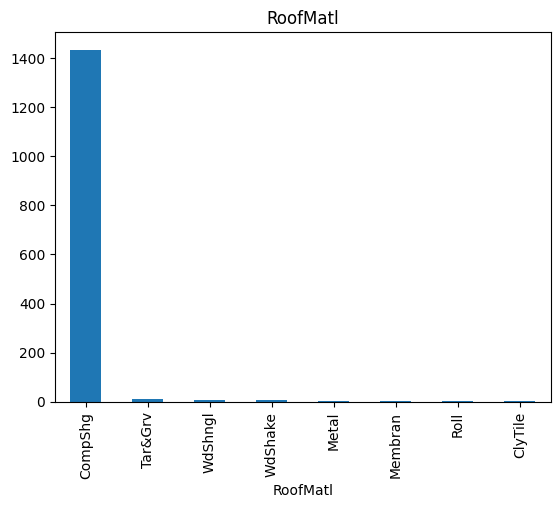

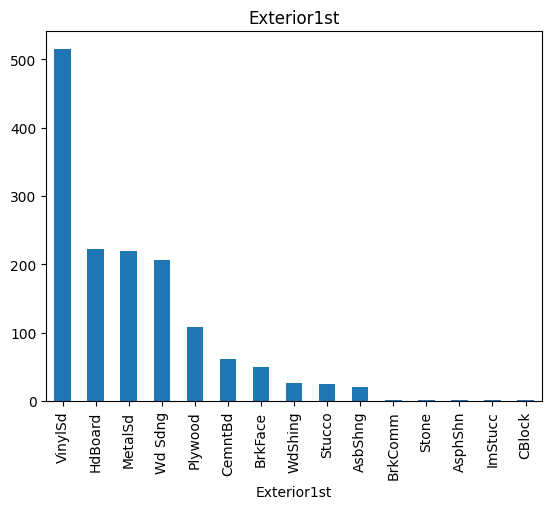

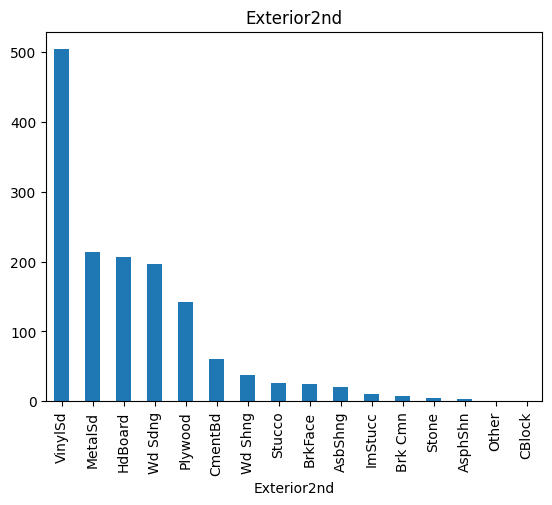

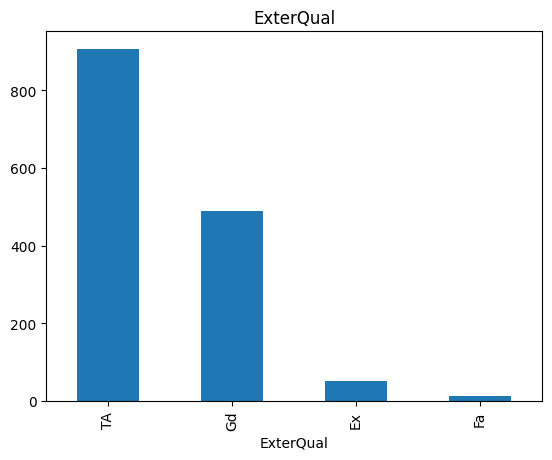

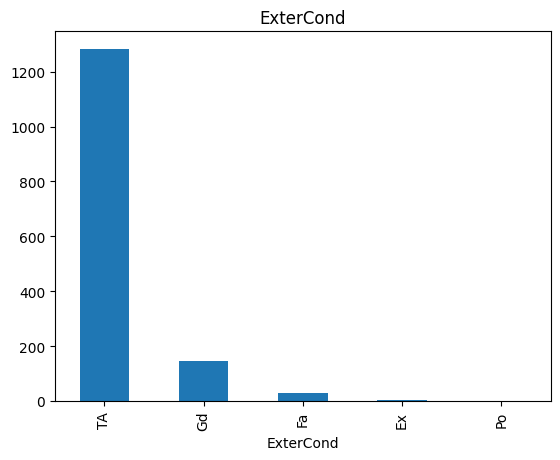

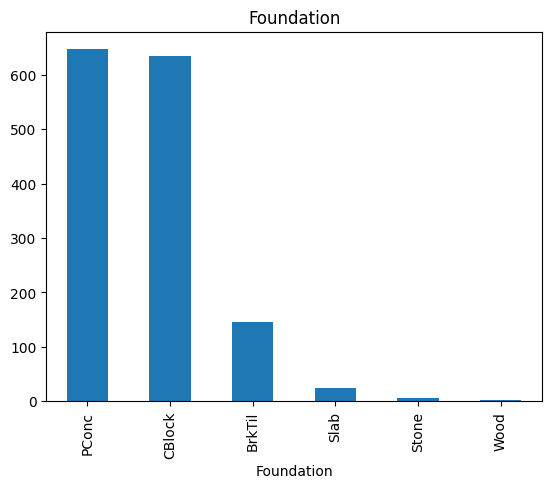

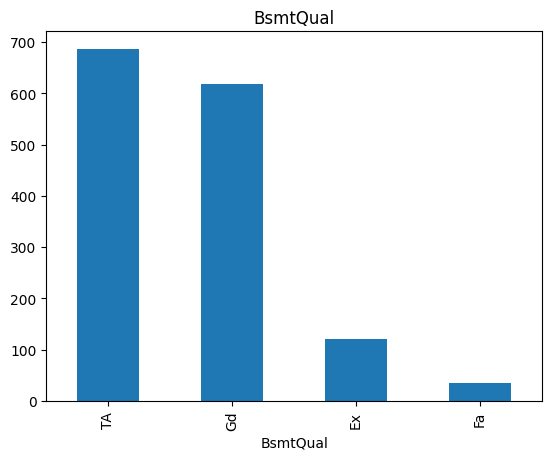

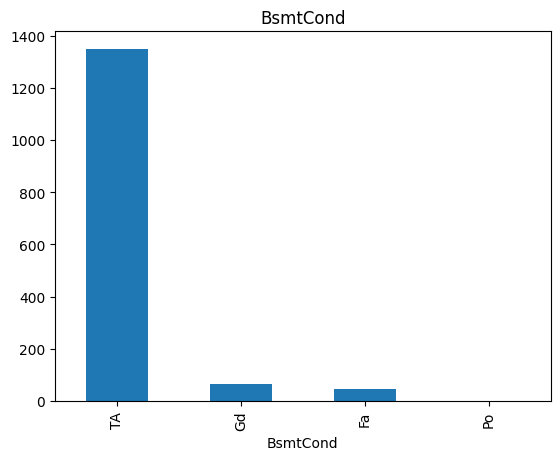

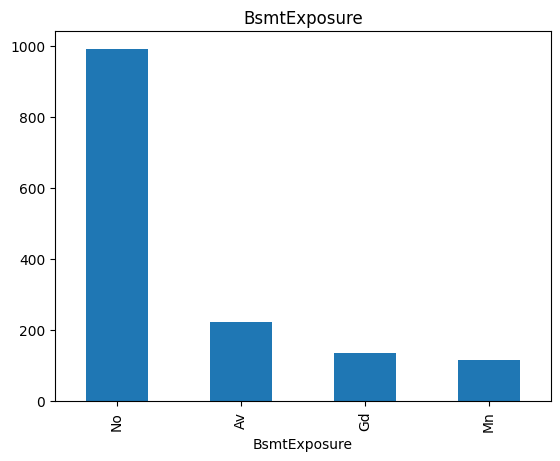

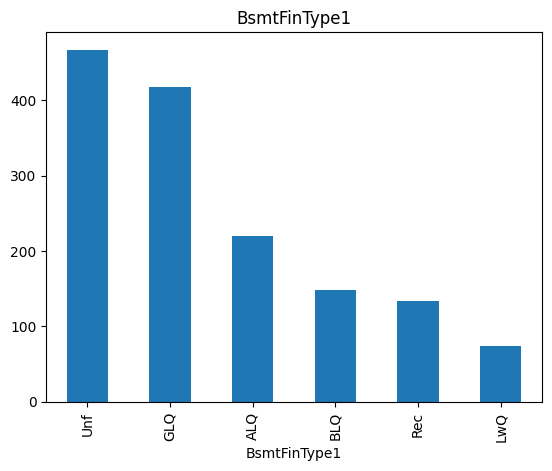

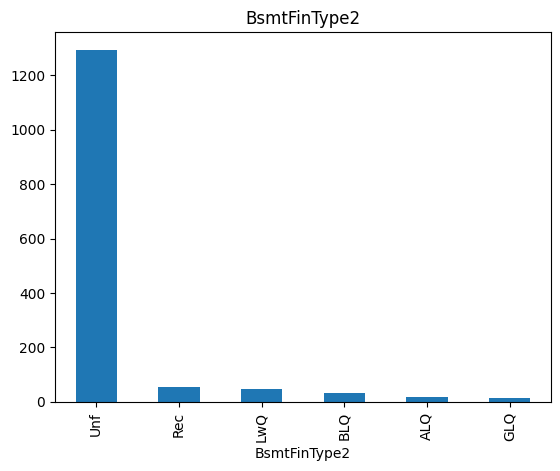

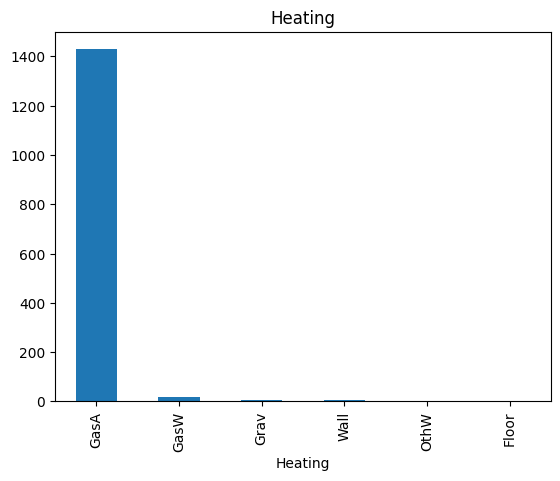

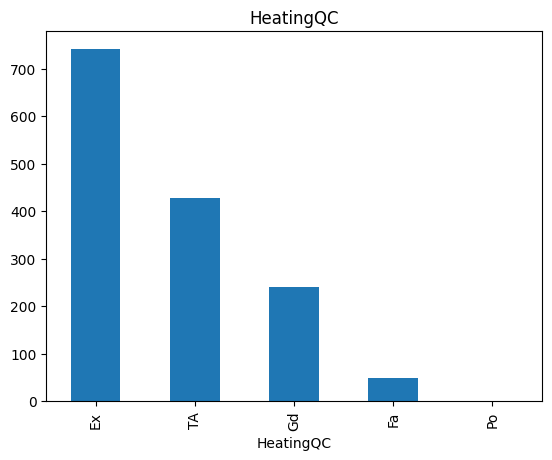

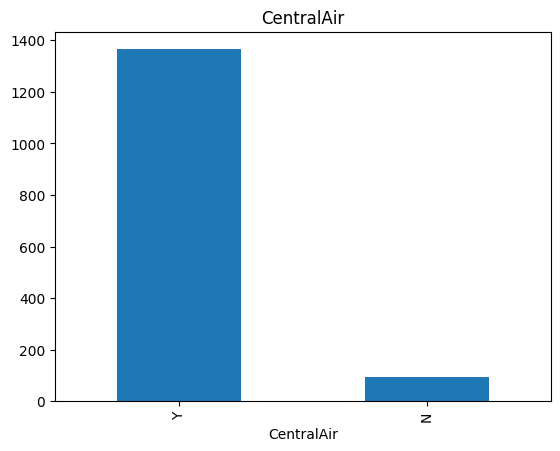

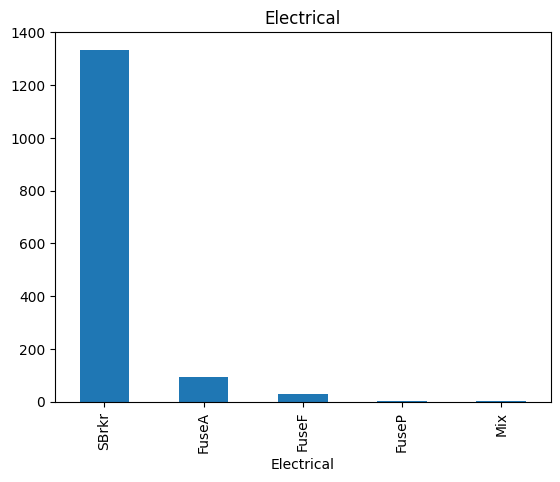

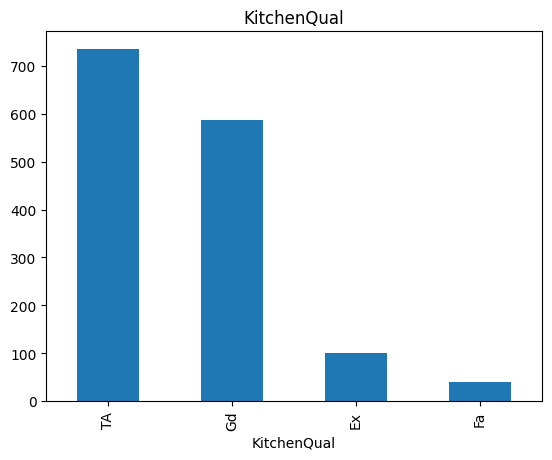

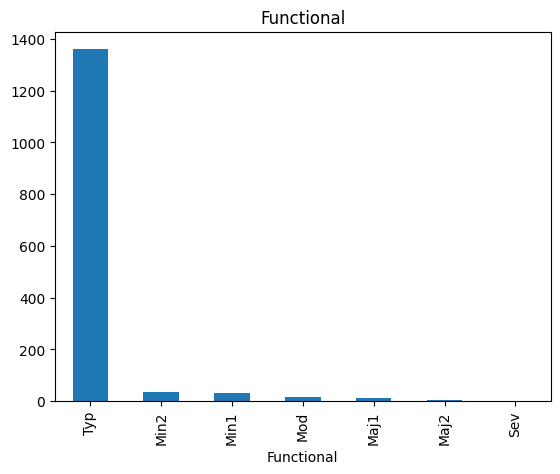

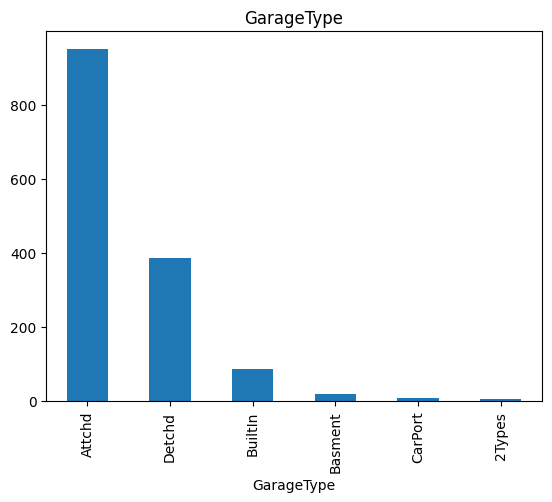

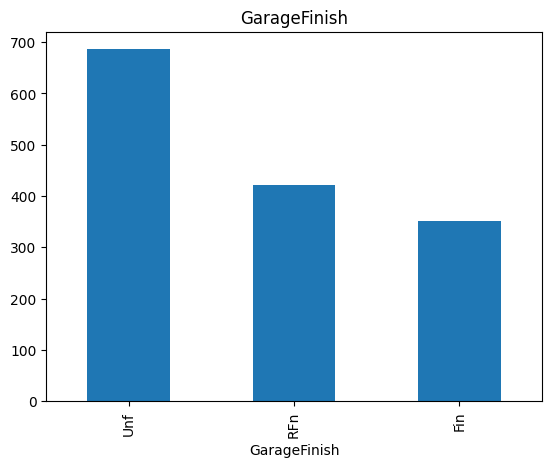

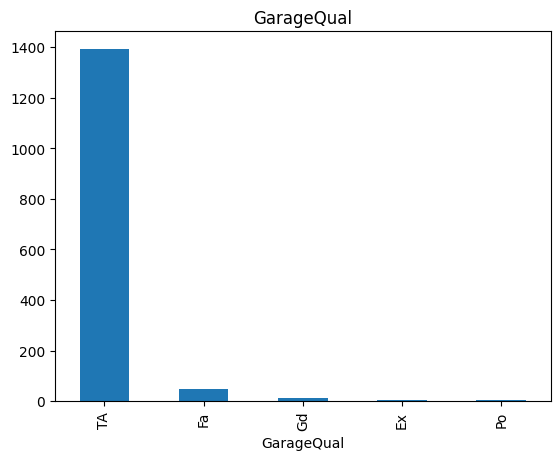

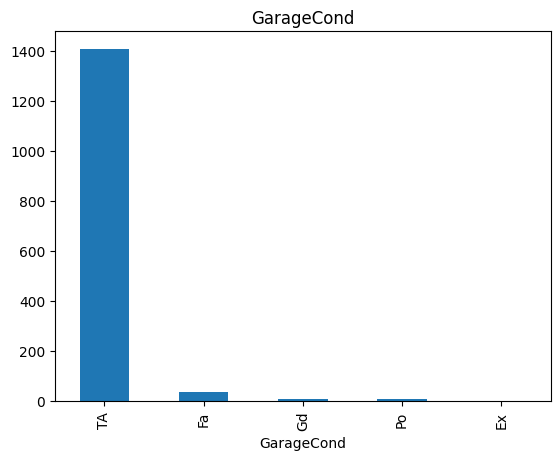

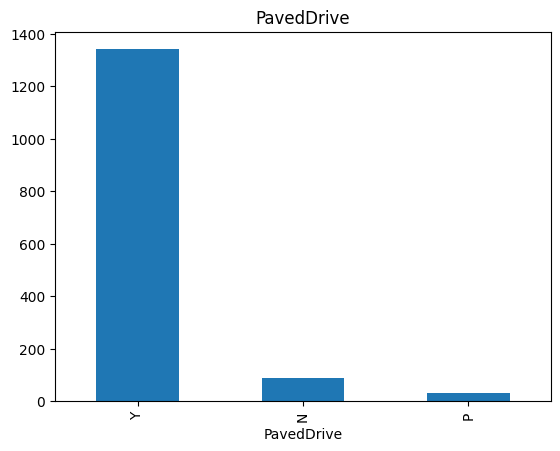

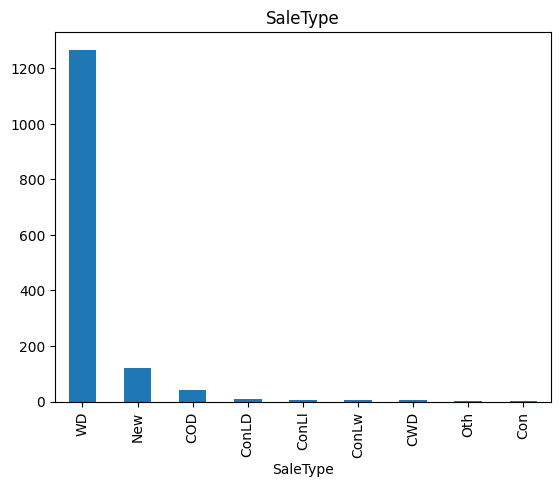

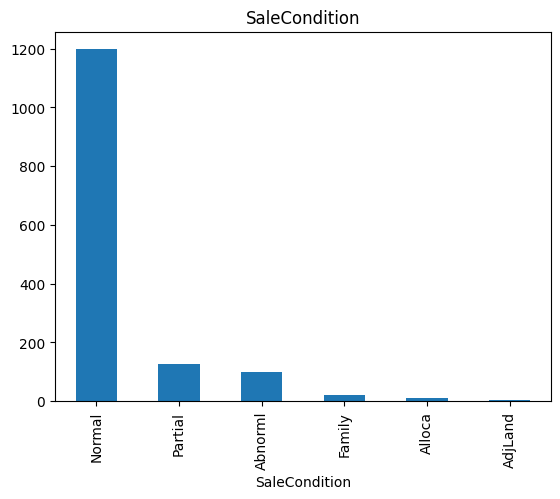

In [53]:
categorical_data = train_df.select_dtypes(include=['object'])
for col in categorical_data.columns:
    train_df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

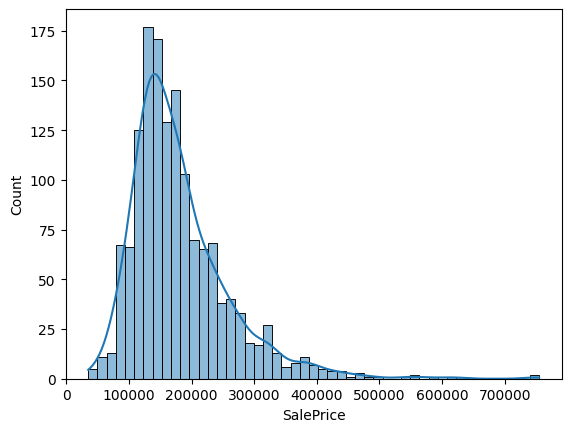

In [54]:
sns.histplot(train_df['SalePrice'], kde=True)

In [55]:
train_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [57]:
cm = train_df.corr(numeric_only=True, )
cm['SalePrice'].sort_values(ascending=False)



SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.475241
GarageYrBlt      0.470177
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334901
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

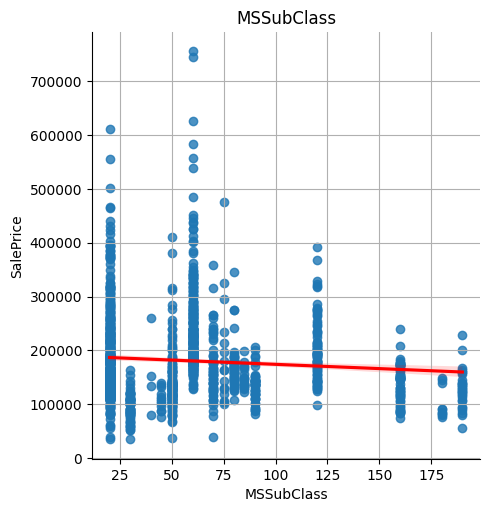

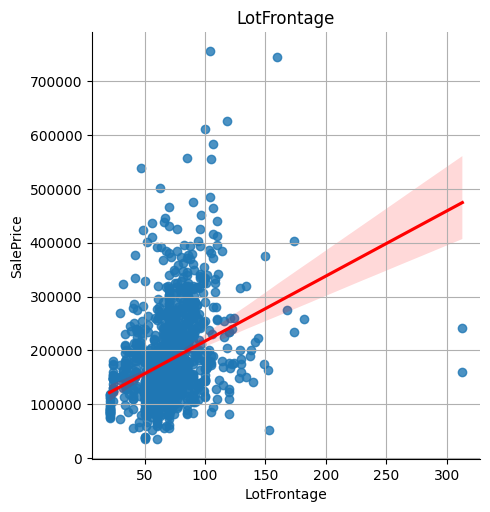

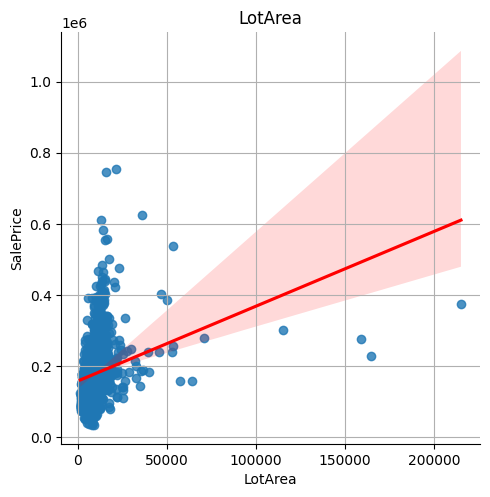

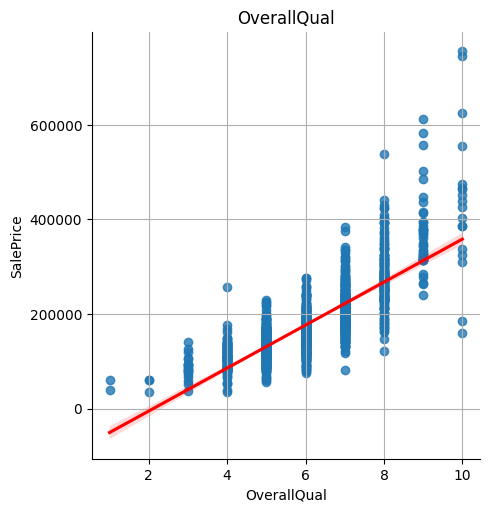

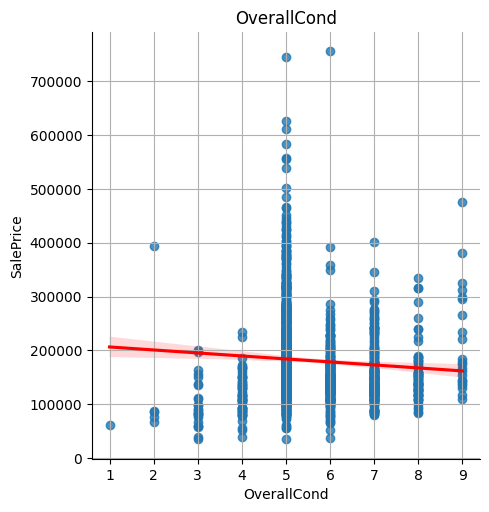

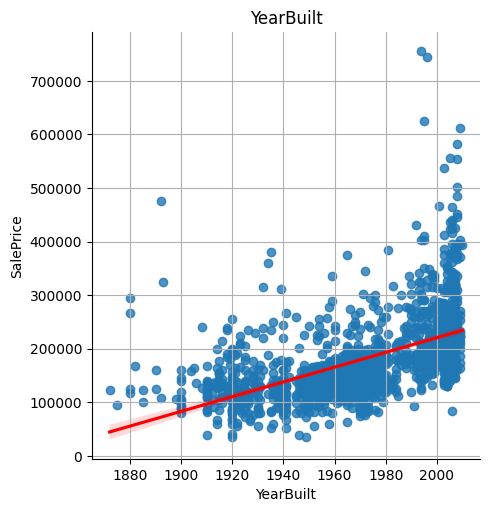

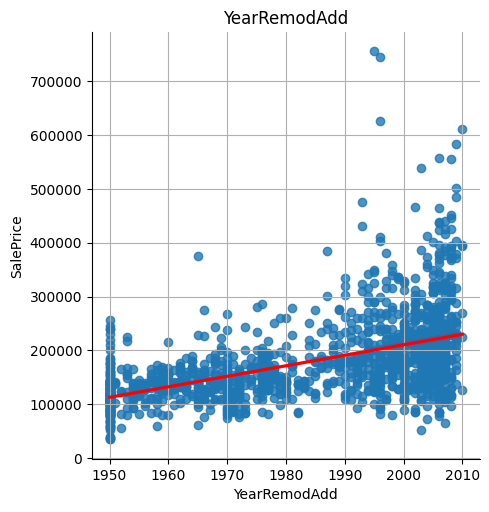

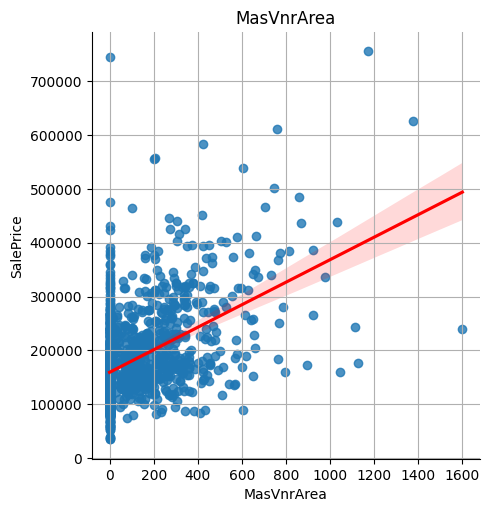

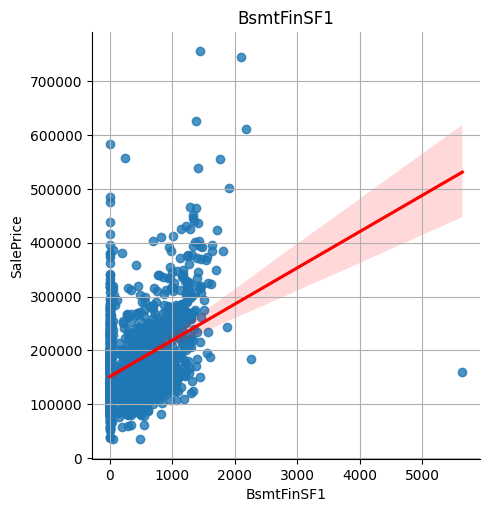

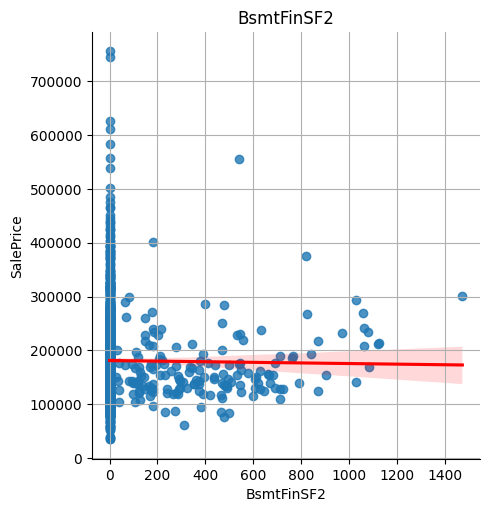

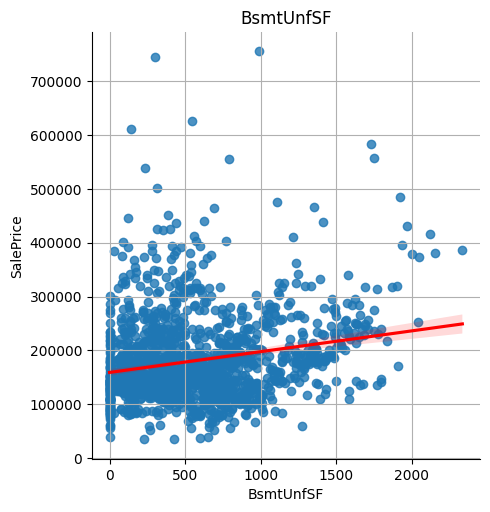

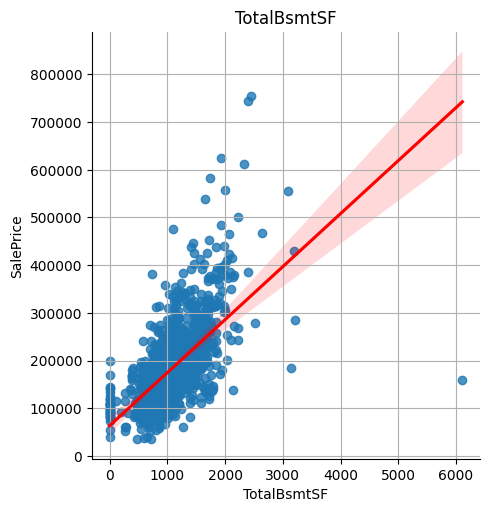

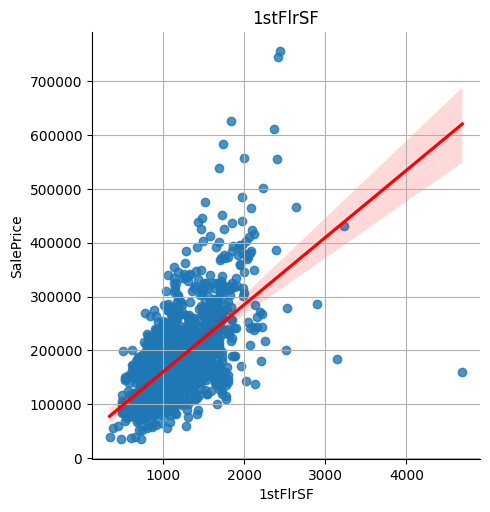

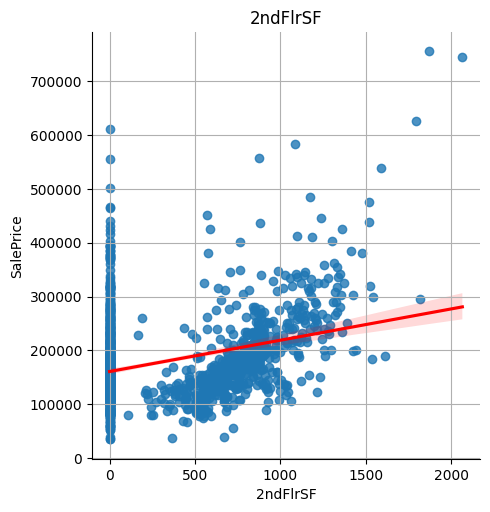

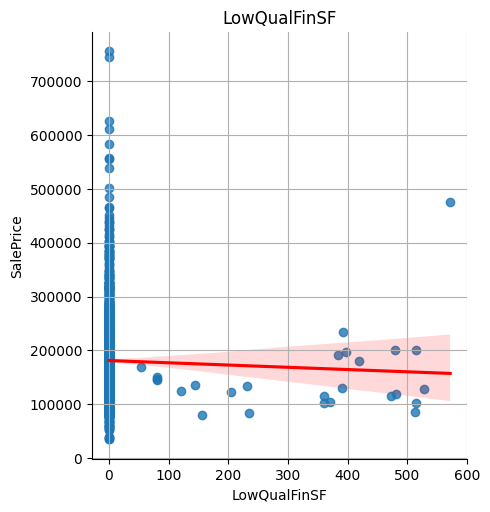

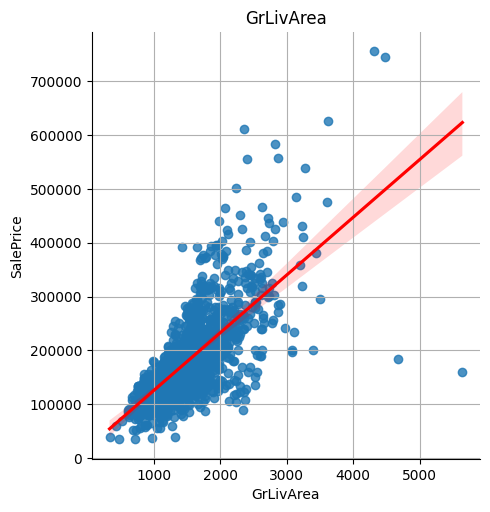

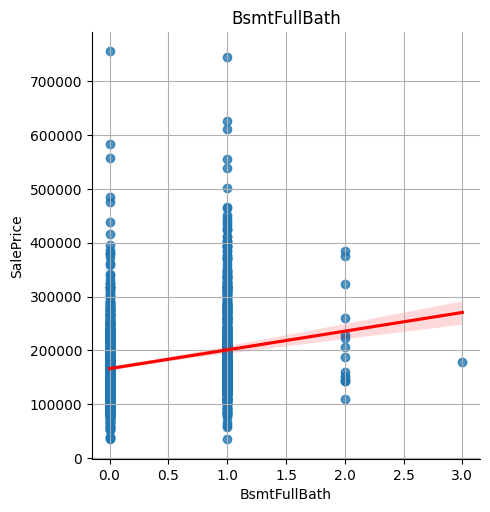

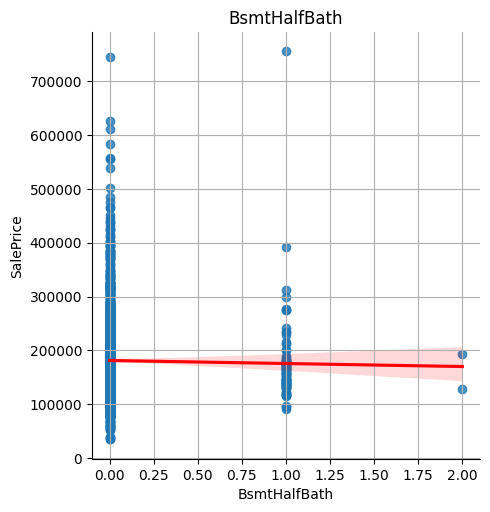

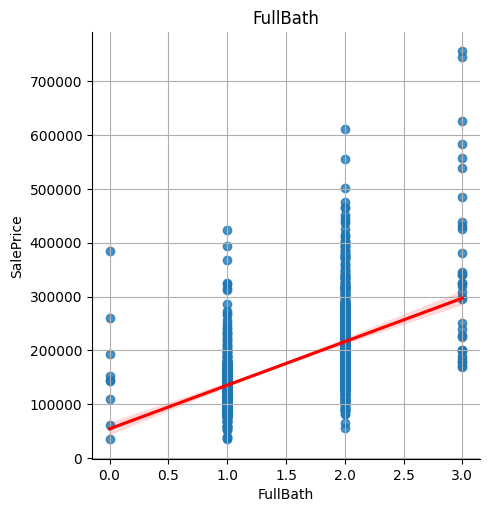

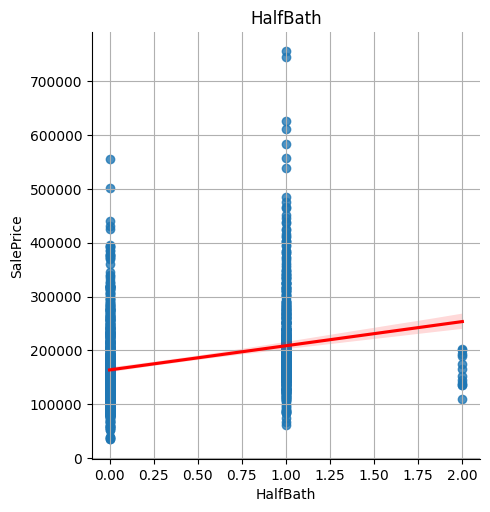

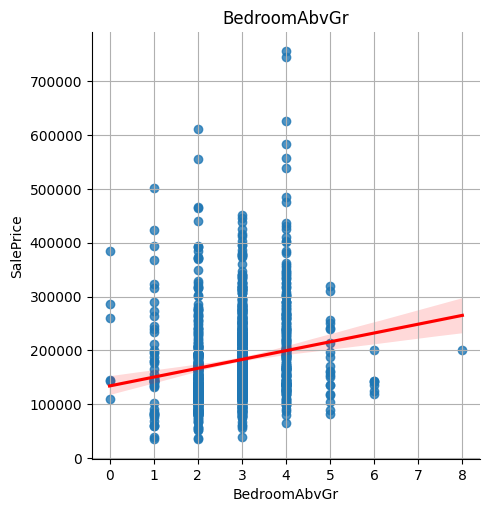

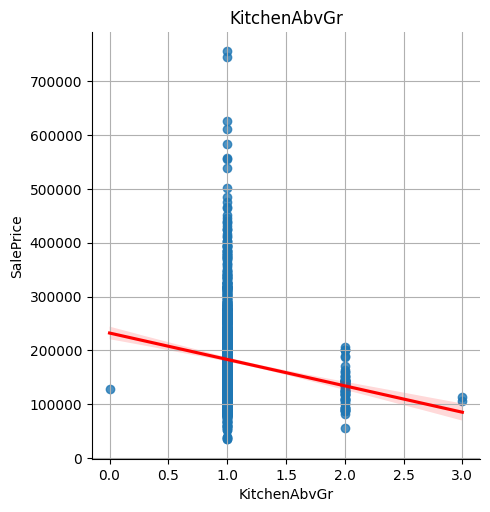

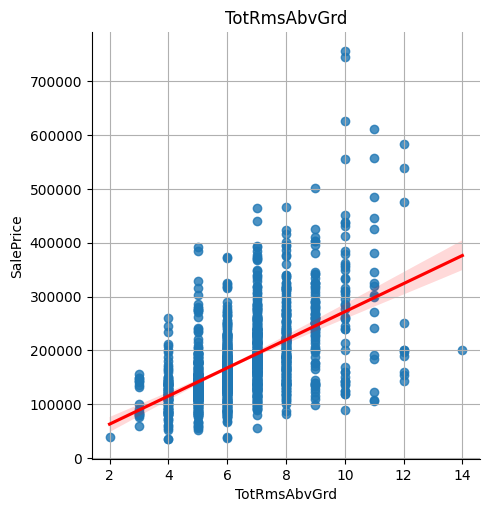

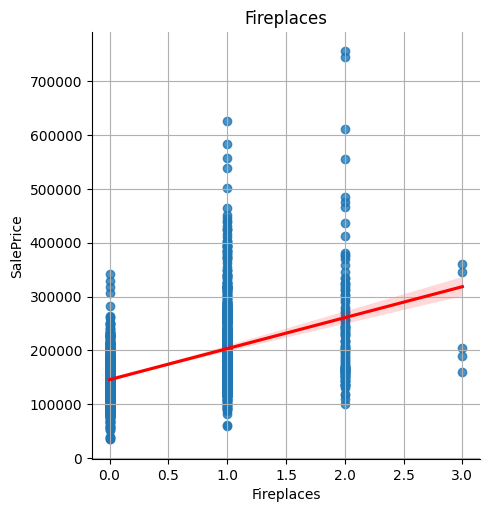

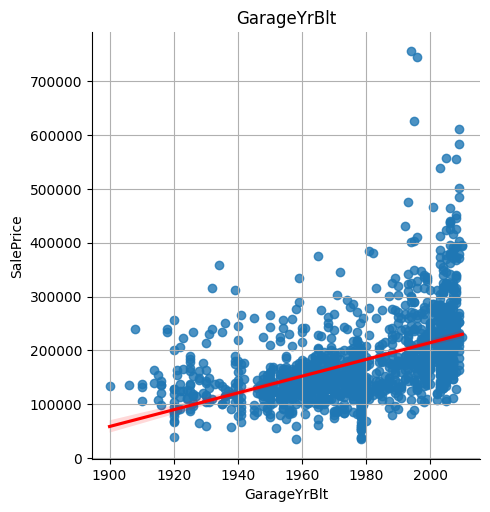

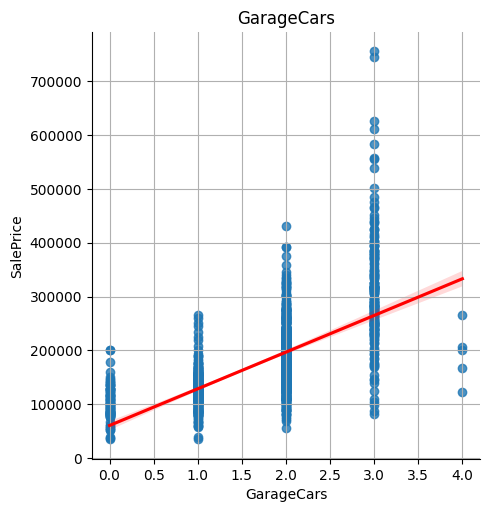

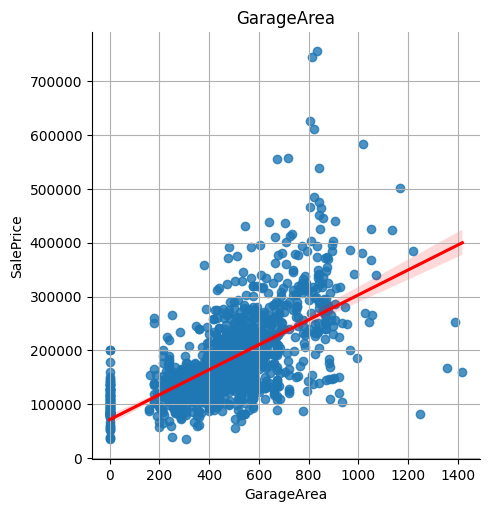

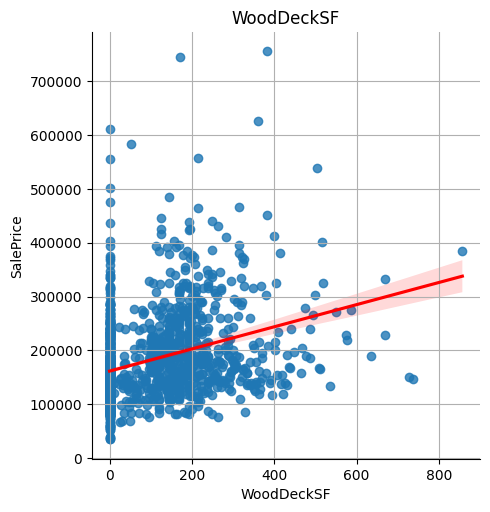

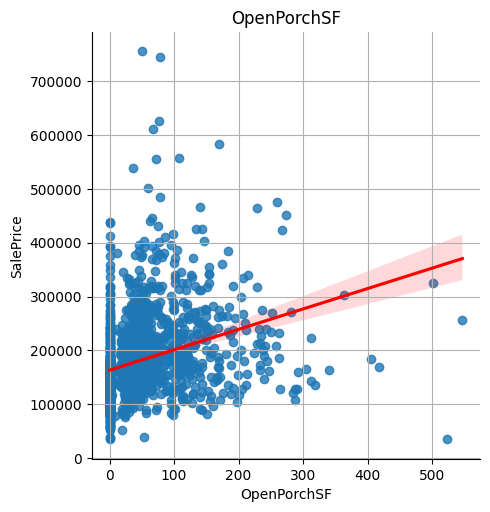

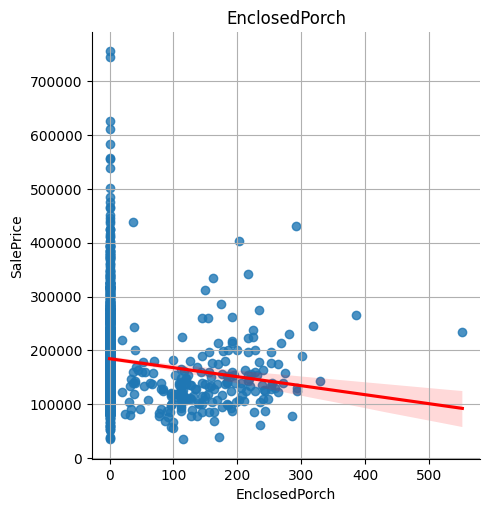

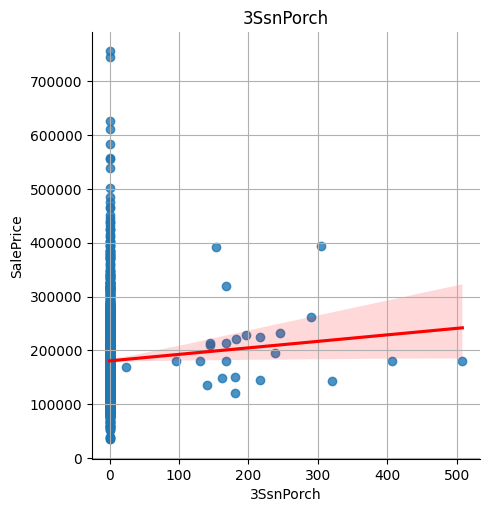

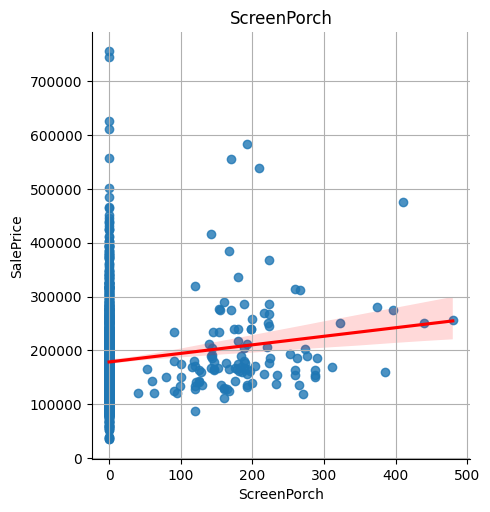

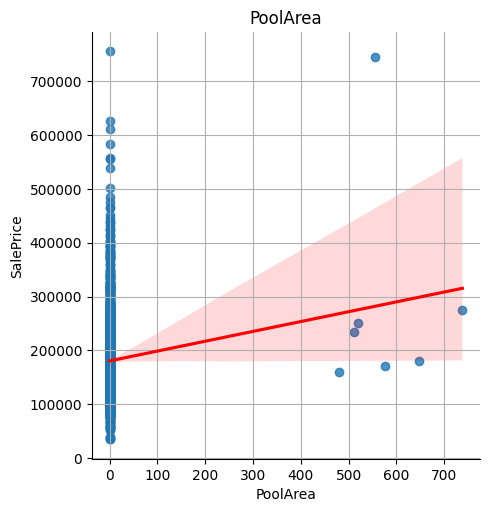

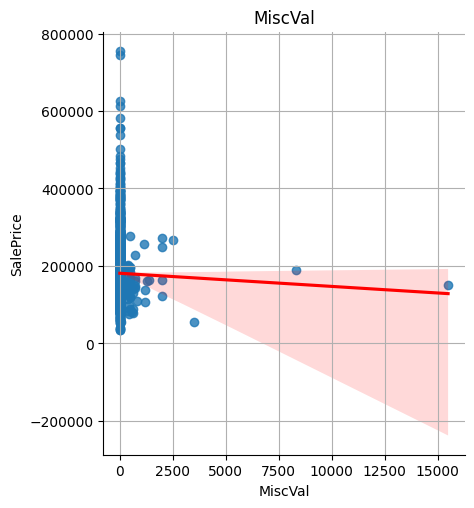

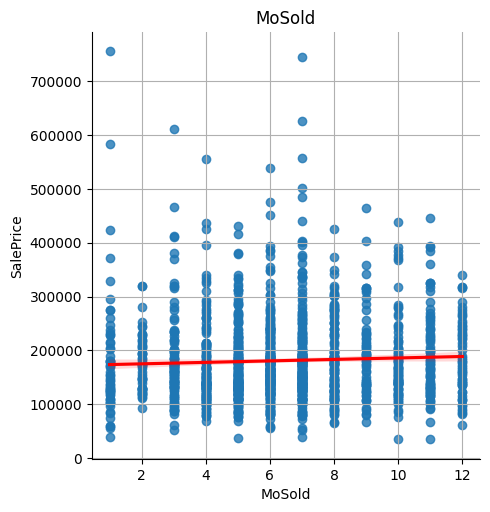

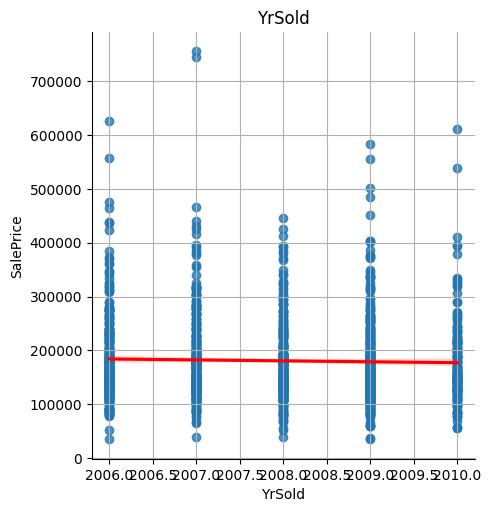

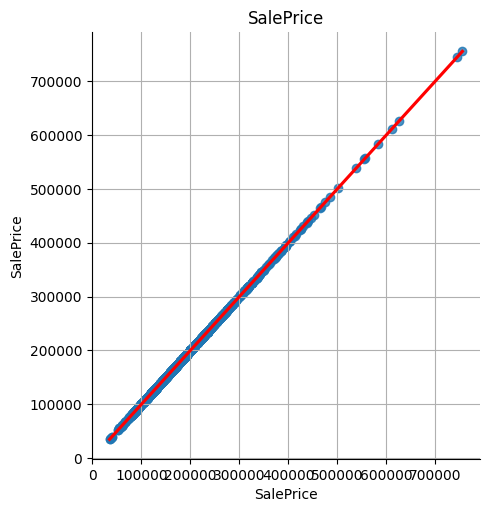

In [58]:
#scatter plot between sale price and overall quality, add line of best fit
for col in numerical_data.columns:
    sns.lmplot(x=col, y='SalePrice', data=train_df, line_kws={'color': 'red'})
    plt.title(col)
    plt.grid(True)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.figsize=(20, 20)
    plt.show()



<Axes: xlabel='OverallQual'>

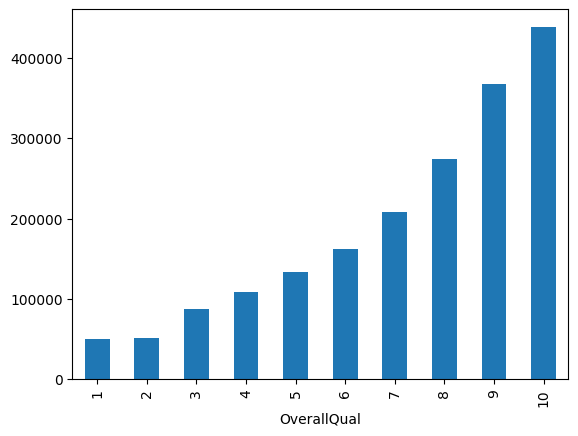

In [59]:
train_df.groupby('OverallQual')['SalePrice'].mean().plot(kind='bar')

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

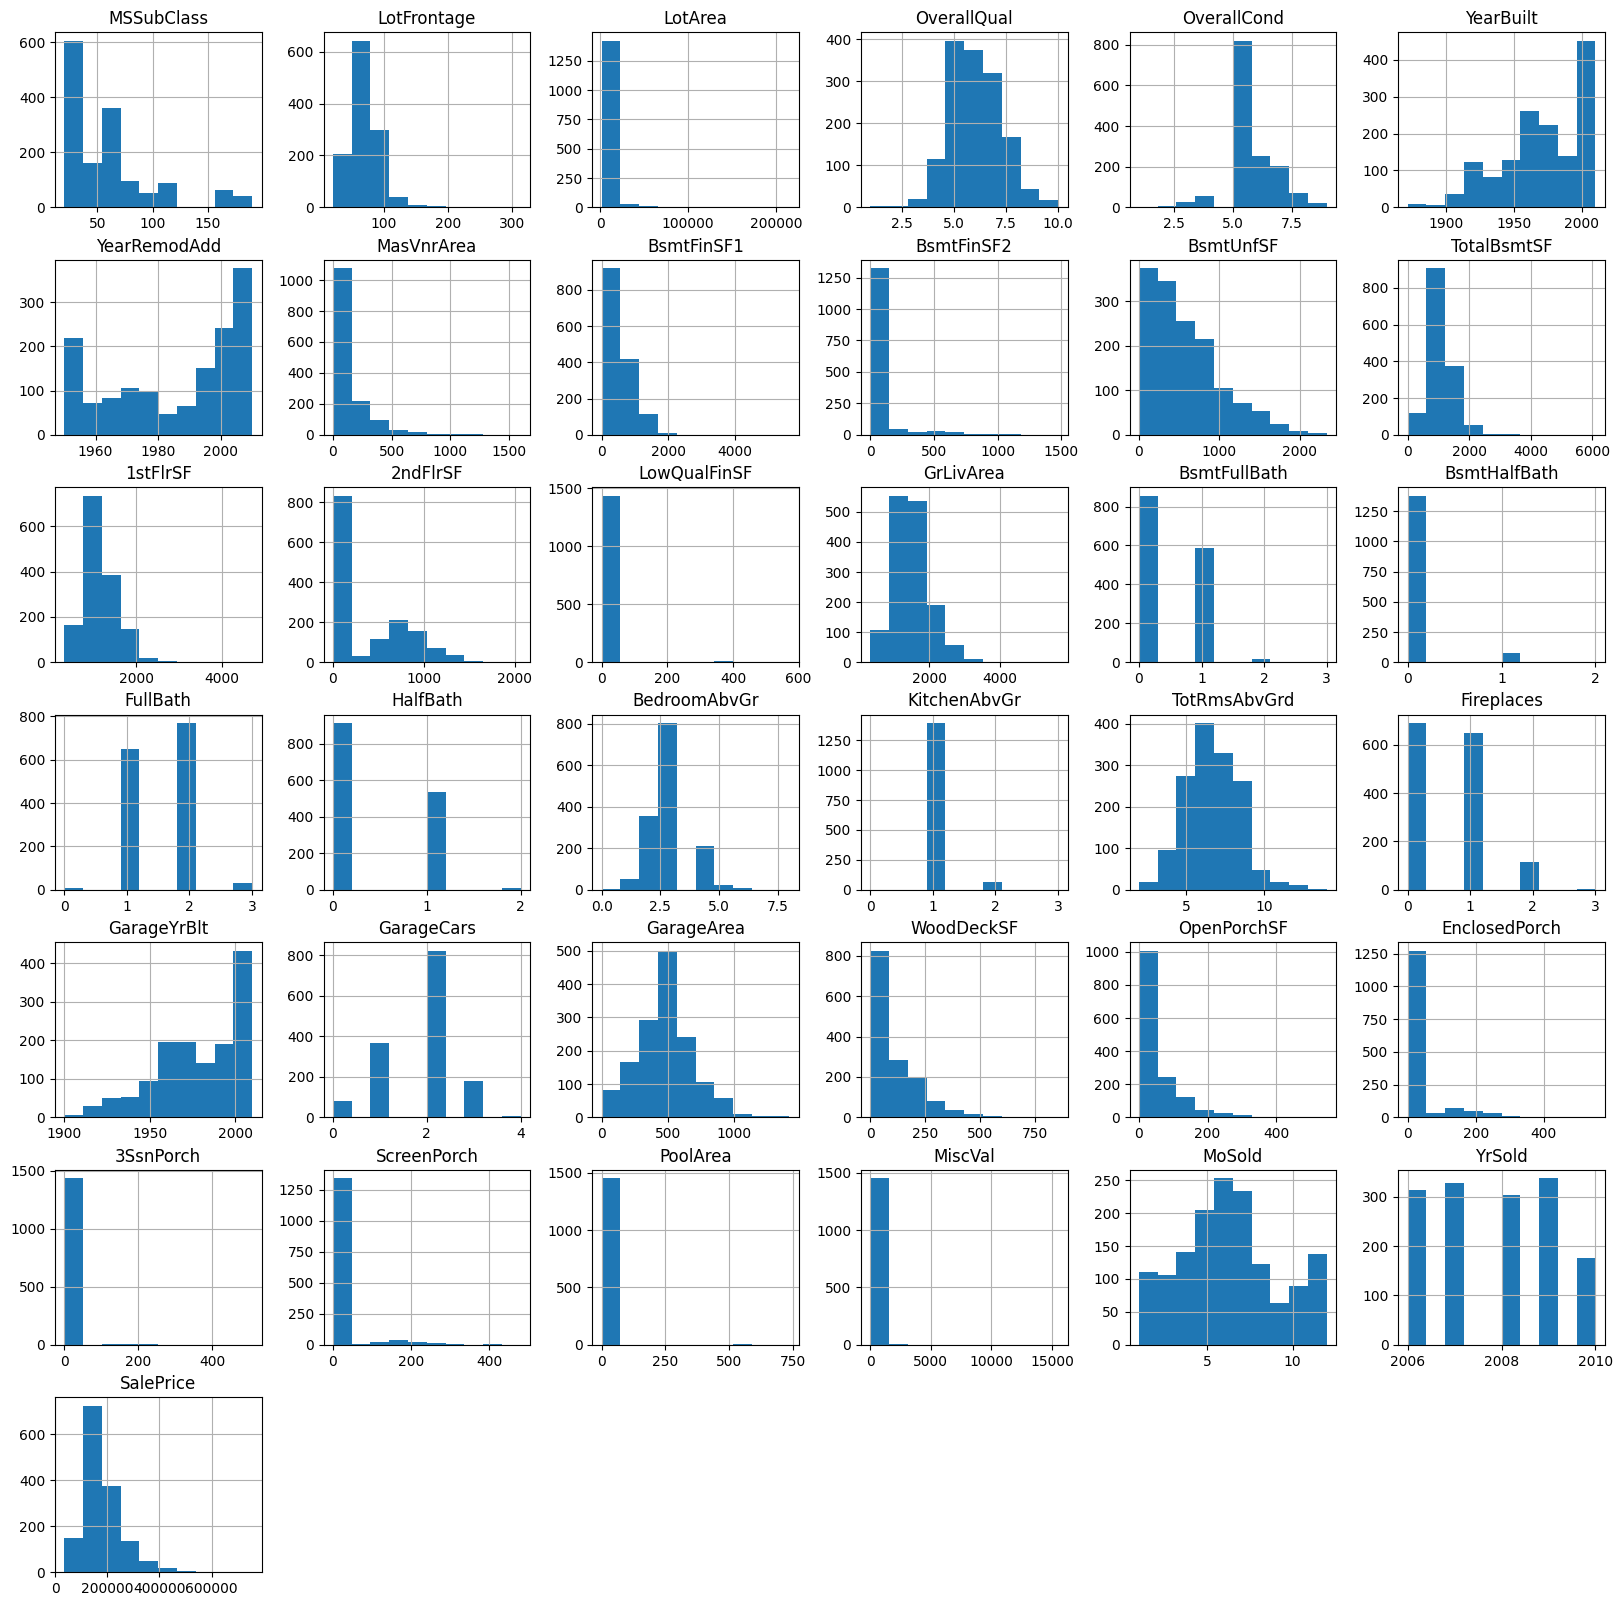

In [60]:
numerical_data.hist(figsize=(20, 20))

In [61]:
train_df = train_df.apply(lambda x: x.astype('category') if x.dtype == 'object' else x)
train_df = train_df.apply(lambda x: x.cat.codes if x.dtype.name == 'category' else x)

In [62]:
train_df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450,1,3,3,0,4,0,...,0,0,0,0,0,2,2008,8,4,208500
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,5,2007,8,4,181500
2,60,3,68.0,11250,1,0,3,0,4,0,...,0,0,0,0,0,9,2008,8,4,223500
3,70,3,60.0,9550,1,0,3,0,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,60,3,84.0,14260,1,0,3,0,2,0,...,0,0,0,0,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917,1,3,3,0,4,0,...,0,0,0,0,0,8,2007,8,4,175000
1456,20,3,85.0,13175,1,3,3,0,4,0,...,0,0,0,0,0,2,2010,8,4,210000
1457,70,3,66.0,9042,1,3,3,0,4,0,...,0,0,0,0,2500,5,2010,8,4,266500
1458,20,3,68.0,9717,1,3,3,0,4,0,...,112,0,0,0,0,4,2010,8,4,142125


In [64]:
train_df.dtypes.unique()

array([dtype('int64'), dtype('int8'), dtype('float64')], dtype=object)

In [65]:
cm = train_df.corr()
cm['SalePrice'].sort_values(ascending=False)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
                  ...   
HeatingQC      -0.400178
GarageFinish   -0.537242
KitchenQual    -0.589189
BsmtQual       -0.618025
ExterQual      -0.636884
Name: SalePrice, Length: 74, dtype: float64

In [66]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int8   
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int8   
 5   LotShape       1460 non-null   int8   
 6   LandContour    1460 non-null   int8   
 7   Utilities      1460 non-null   int8   
 8   LotConfig      1460 non-null   int8   
 9   LandSlope      1460 non-null   int8   
 10  Neighborhood   1460 non-null   int8   
 11  Condition1     1460 non-null   int8   
 12  Condition2     1460 non-null   int8   
 13  BldgType       1460 non-null   int8   
 14  HouseStyle     1460 non-null   int8   
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [67]:
#import train test split
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
#Lasso model
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Standardizing the data
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)


In [69]:
Lasso_model = Lasso(alpha=0.1)
Lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [70]:
y_pred = Lasso_model.predict(X_test_scaled)

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

In [74]:
def eval_model(y_true, y_predictions):
    print(f"Mean Squared Error: {mean_squared_error(y_true, y_predictions)}")
    print(f"R2 Score: {r2_score(y_true, y_predictions)}")


In [75]:
#Lasso model evaluation
eval_model(y_test, y_pred)

Mean Squared Error: 1184759412.055152
R2 Score: 0.8455398923001439


In [76]:
from sklearn.linear_model import Ridge

In [77]:

# Ridge Regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)


Ridge(alpha=0.1)

In [78]:
y_pred_ridge = ridge_model.predict(X_test_scaled)


In [79]:
#evaluate ridge regression model
eval_model(y_test, y_pred_ridge)

Mean Squared Error: 1184733378.718921
R2 Score: 0.8455432863326175


In [80]:
from sklearn.linear_model import BayesianRidge

In [81]:
#Bayesian ridge regression model
BayesianRidge_model = BayesianRidge()
BayesianRidge_model.fit(X_train_scaled, y_train)

BayesianRidge()

In [82]:
y_pred_bayesian = BayesianRidge_model.predict(X_test_scaled)

In [83]:
#evaluate bayesian ridge regression model
eval_model(y_test, y_pred_bayesian)

Mean Squared Error: 1173204459.4975164
R2 Score: 0.8470463409498518


In [84]:
# Coefficients
print("Coefficients:", BayesianRidge_model.coef_)

# Standard deviation of the predictions
print("Prediction Uncertainty:", BayesianRidge_model.sigma_)


Coefficients: [-5083.97523577 -1261.9679415  -4384.92000036  3268.03257952
  1154.64031345 -1635.95994227  1988.57899453 -1303.72063903
  -155.25868873  3234.83196474  2649.57343779  -244.23422811
 -2260.51228599 -2709.78945011 -2364.28522914 14700.07536305
  4283.75154133  3903.15345894  2298.16948798  2471.89133572
  2388.89327103 -3279.39008356  1552.44311034  3221.06510715
 -5523.34083771   104.86235051  1331.49816142 -8702.10891983
  2348.00941788 -4096.33206252 -1289.00426727  2276.56783608
   592.67966951   813.8606212   -675.35911139  1979.72250238
  -213.70347677  -840.57492611   447.28135091  -479.12563017
  6696.05146717  7783.69480372    95.82716038 11470.05526997
  4048.21874456  -328.22774287  2499.18819607   405.12177024
 -1356.90754961 -2657.39481083 -7878.40476858  5905.57876217
  4181.88441984  3962.20593158 -1152.42149463  -402.29282388
  -171.14796268  6699.13636805  1930.91084524  -237.17042231
  1224.11737568   450.56962983  1823.37668578  -996.84029743
   -81.020

In [100]:
#decision tree regressor
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regression model
dt_model = DecisionTreeRegressor( random_state=42)

In [101]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [102]:
y_pred_dt = dt_model.predict(X_test)

In [103]:
eval_model(y_test, y_pred_dt)

Mean Squared Error: 1490390601.0547945
R2 Score: 0.8056939743112499


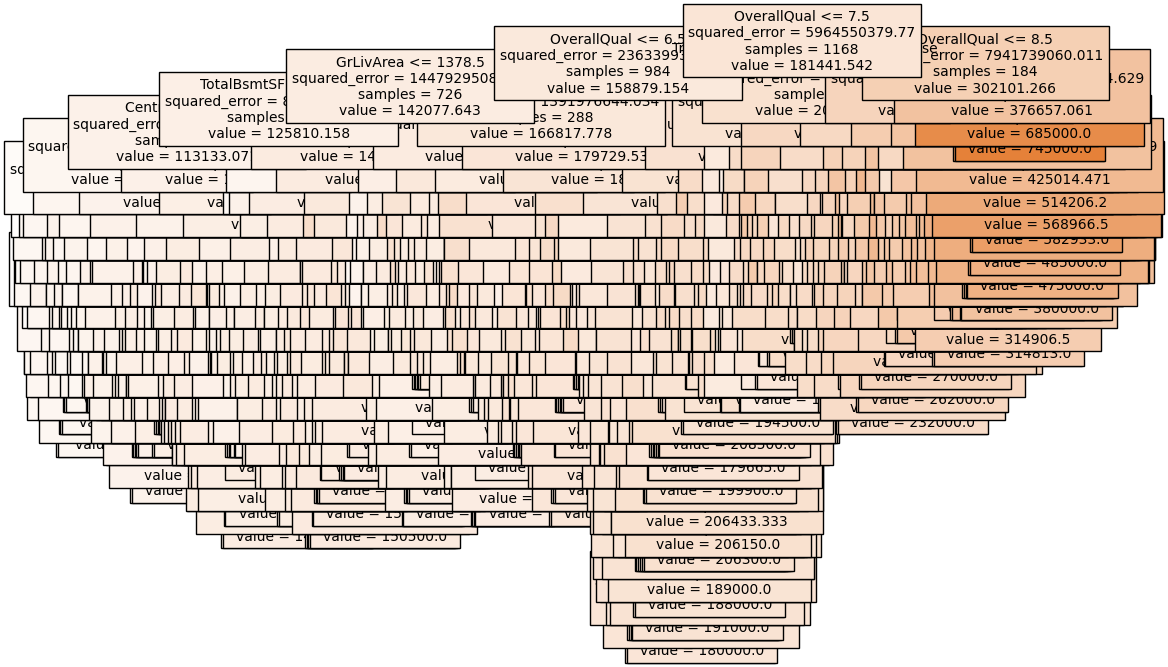

In [104]:
from sklearn.tree import plot_tree

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=X.columns, filled=True, fontsize=10)
plt.show()

In [108]:
from sklearn.svm import SVR


# Support Vector Regression model
svr_model = SVR(kernel='rbf')

In [106]:
y_train_scaled = scalar.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scalar.transform(y_test.values.reshape(-1, 1))

In [109]:
svr_model.fit(X_train_scaled, y_train_scaled.ravel())

SVR()

In [110]:
y_pred_svr = svr_model.predict(X_test_scaled)
y_pred_svr = scalar.inverse_transform(y_pred_svr.reshape(-1, 1))
y_test_inv = scalar.inverse_transform(y_test_scaled)

In [111]:
eval_model(y_test_inv, y_pred_svr)

Mean Squared Error: 1890996181.4483337
R2 Score: 0.7534660025702085


In [112]:
from sklearn.neighbors import KNeighborsRegressor


# K-Nearest Neighbors Regression model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [113]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [114]:
eval_model(y_test, y_pred_knn)

Mean Squared Error: 1659180792.139452
R2 Score: 0.7836883663976647


In [129]:
from sklearn.neural_network import MLPRegressor


# Initialize the MLPRegressor model
mlp_model = MLPRegressor(hidden_layer_sizes=(650,), activation='relu', solver='adam', random_state=42, max_iter=500)

# Train the model
mlp_model.fit(X_train_scaled, y_train_scaled.ravel())



MLPRegressor(hidden_layer_sizes=(650,), max_iter=500, random_state=42)

In [130]:
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_pred_mlp = scalar.inverse_transform(y_pred_mlp.reshape(-1, 1))
y_test_inv_mlp = scalar.inverse_transform(y_test_scaled)
eval_model(y_test_inv_mlp, y_pred_mlp)

Mean Squared Error: 893186017.4328521
R2 Score: 0.8835530597647941
